# Geometric Superposition Search (GSS)

**Research Notebook**: Can deterministic geometric beam search replace stochastic MCTS?

Core hypothesis:
- **Cl(3,0)** state algebra: equivariant policy (rotor groups) + invariant value (grade-0)
- **Bivector norm** as exploration signal (FIM-like uncertainty proxy)
- **Cl(1,1)** search algebra: `tanh(theta)` from hyperbolic rotors as geometric exploration rate
- **Entropy gating**: suppress disordered beam states via bivector Shannon entropy

Test environments: 10-armed bandit, chain MDP, grid maze

## Section 0 -- Setup & Algebra Inspection

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'versor'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math, random
from typing import List, Tuple, Dict
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

from core.algebra import CliffordAlgebra
from core.metric import induced_norm, inner_product, geometric_distance
from layers import EntropyGatedAttention

alg30 = CliffordAlgebra(3, 0, device='cpu')  # state algebra, dim=8
alg11 = CliffordAlgebra(1, 1, device='cpu')  # search algebra, dim=4

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print('=== Cl(3,0) State Algebra ===')
print(f'  n={alg30.n}  dim=2^n={alg30.dim}  exp={alg30._exp_regime}')
for k in range(alg30.num_grades):
    idx = alg30.grade_masks[k].nonzero(as_tuple=False).squeeze(-1).tolist()
    print(f'  grade-{k}: {len(idx)} elts  idx={idx}')

print('\n=== Cl(1,1) Search Algebra ===')
print(f'  n={alg11.n}  dim=2^n={alg11.dim}  exp={alg11._exp_regime}')
for k in range(alg11.num_grades):
    idx = alg11.grade_masks[k].nonzero(as_tuple=False).squeeze(-1).tolist()
    print(f'  grade-{k}: {len(idx)} elts  idx={idx}')
print(f'  bv_sq_scalar (e01^2 sign) = {alg11.bv_sq_scalar.tolist()} => hyperbolic bivector')

=== Cl(3,0) State Algebra ===
  n=3  dim=2^n=8  exp=elliptic
  grade-0: 1 elts  idx=[0]
  grade-1: 3 elts  idx=[1, 2, 4]
  grade-2: 3 elts  idx=[3, 5, 6]
  grade-3: 1 elts  idx=[7]

=== Cl(1,1) Search Algebra ===
  n=2  dim=2^n=4  exp=mixed
  grade-0: 1 elts  idx=[0]
  grade-1: 2 elts  idx=[1, 2]
  grade-2: 1 elts  idx=[3]
  bv_sq_scalar (e01^2 sign) = [1.0] => hyperbolic bivector


## Section 1 -- Bivector Uncertainty (FIM Connection)

For unit vectors $x, y \in \mathrm{Cl}(3,0)$, the grade-2 part of $xy$ is the wedge product:

$$\|x \wedge y\| = \sin(\angle(x,y))$$

High bivector norm $\Leftrightarrow$ large angular separation $\Leftrightarrow$ high relational uncertainty (FIM analogy).

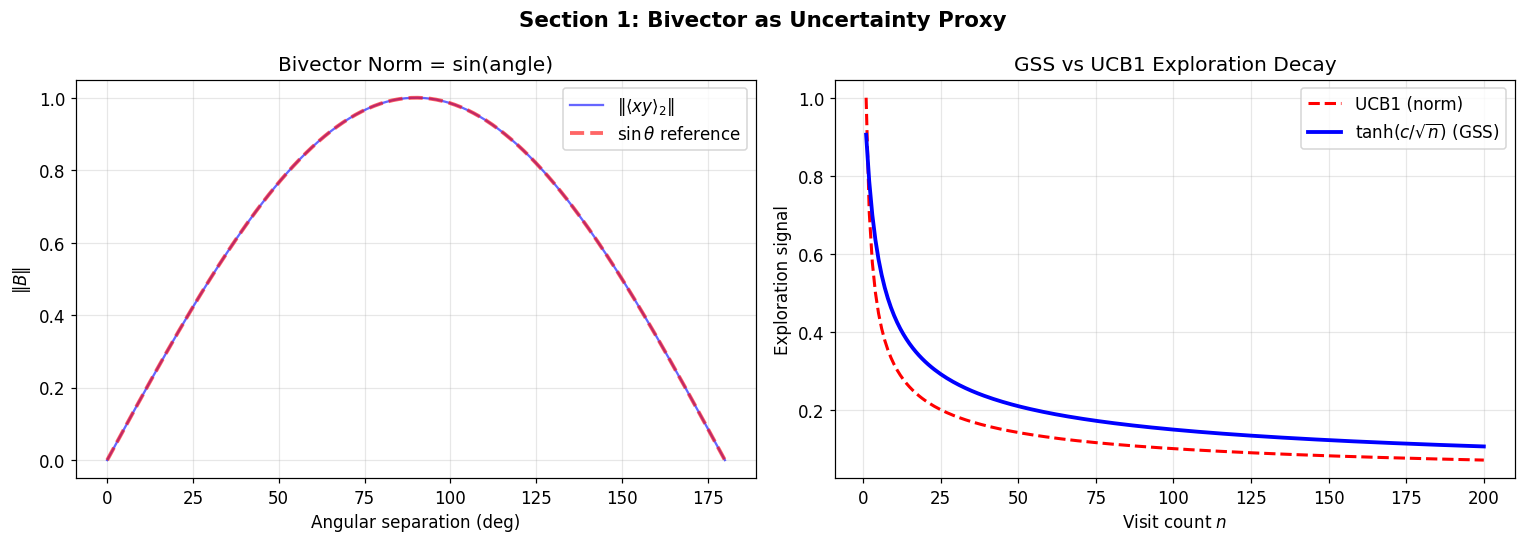

In [33]:
angles = np.linspace(0, np.pi, 200)
bv_norms = []
for angle in angles:
    x = torch.zeros(alg30.dim); x[1] = 1.0
    y = torch.zeros(alg30.dim); y[1] = math.cos(angle); y[2] = math.sin(angle)
    xy = alg30.geometric_product(x.unsqueeze(0), y.unsqueeze(0)).squeeze(0)
    bv_norms.append(alg30.grade_projection(xy, 2).norm().item())
bv_norms = np.array(bv_norms)

n_arr = np.arange(1, 201)
ucb1 = np.sqrt(2 * np.log(1000) / n_arr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(np.degrees(angles), bv_norms, 'b-', lw=1.5, alpha=.6, label=r'$\|\langle xy\rangle_2\|$')
axes[0].plot(np.degrees(angles), np.sin(angles), 'r--', lw=2.5, alpha=.6, label=r'$\sin\theta$ reference')
axes[0].set_xlabel('Angular separation (deg)'); axes[0].set_ylabel(r'$\|B\|$')
axes[0].set_title('Bivector Norm = sin(angle)'); axes[0].legend(); axes[0].grid(True, alpha=.3)

axes[1].plot(n_arr, ucb1 / ucb1.max(), 'r--', lw=2, label='UCB1 (norm)')
axes[1].plot(n_arr, np.tanh(1.5 / np.sqrt(n_arr)), 'b-', lw=2.5, label=r'$\tanh(c/\sqrt{n})$ (GSS)')
axes[1].set_xlabel('Visit count $n$'); axes[1].set_ylabel('Exploration signal')
axes[1].set_title('GSS vs UCB1 Exploration Decay'); axes[1].legend(); axes[1].grid(True, alpha=.3)

plt.suptitle('Section 1: Bivector as Uncertainty Proxy', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

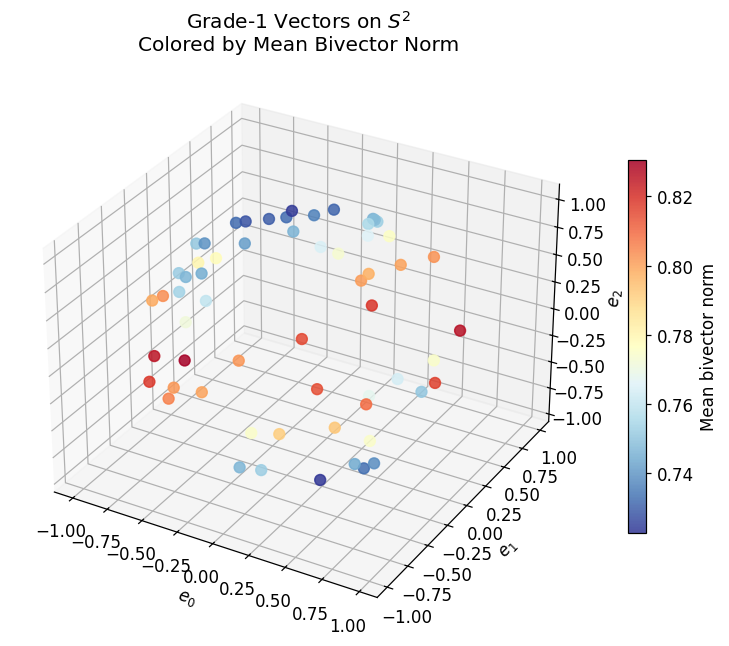

In [3]:
# 3D: random unit vectors colored by mean bivector norm with all other points
torch.manual_seed(0)
vecs = torch.randn(60, 3)
vecs = vecs / vecs.norm(dim=1, keepdim=True)
mvs = alg30.embed_vector(vecs)

mean_bv = []
for i in range(len(vecs)):
    prods = alg30.geometric_product(mvs[i:i+1].expand(len(vecs), -1), mvs)
    mean_bv.append(alg30.grade_projection(prods, 2).norm(dim=-1).mean().item())

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(vecs[:,0], vecs[:,1], vecs[:,2], c=mean_bv, cmap='RdYlBu_r', s=50, alpha=.85)
plt.colorbar(sc, ax=ax, shrink=.65, label='Mean bivector norm')
ax.set_title('Grade-1 Vectors on $S^2$\nColored by Mean Bivector Norm')
ax.set_xlabel(r'$e_0$'); ax.set_ylabel(r'$e_1$'); ax.set_zlabel(r'$e_2$')
plt.tight_layout(); plt.show()

### Proposition 1: Bivector Norm as Information Metric

**Claim**: For a policy $\pi_\theta$ parameterized by a Cl(3,0) rotor $R(\theta) = \exp(-\theta B/2)$, the Fisher Information satisfies:

$$\mathcal{F} \propto \|B\|^2$$

**Sketch**: The policy acts via sandwich product $x' = Rx\tilde{R}$. Differentiating:

$$\frac{\partial x'}{\partial\theta} = -\tfrac{1}{2}(Bx\tilde{R} + RxB^\dagger)$$

so the FIM entry for a single-parameter rotor reduces to $\mathcal{F} \propto \|B\|^2$. The **bivector norm is a first-order proxy for the local curvature** of the policy log-likelihood.

**Connection to regret**: The Lai-Robbins lower bound involves $D_{\text{KL}}(p_a \| p^*) \approx \tfrac{1}{2}\delta\theta^\top \mathcal{F}\, \delta\theta$. High $\|B\|$ $\Rightarrow$ high curvature $\Rightarrow$ more information per observation $\Rightarrow$ **lower regret per visit**. This justifies using $\|B\|$ as an exploration bonus: arms with high bivector energy are geometrically "informative".

## Section 2 -- Cl(1,1) Search Algebra

In $\mathrm{Cl}(1,1)$: $e_0^2=+1$, $e_1^2=-1$, so $(e_{01})^2 = +1$ (hyperbolic).

$$R = \exp(\theta\, e_{01}) = \cosh\theta + \sinh\theta\, e_{01}$$

The ratio $\tanh\theta = \langle R \rangle_2 / \langle R \rangle_0$ lives in $(-1,1)$ -- a geometrically principled exploration rate.

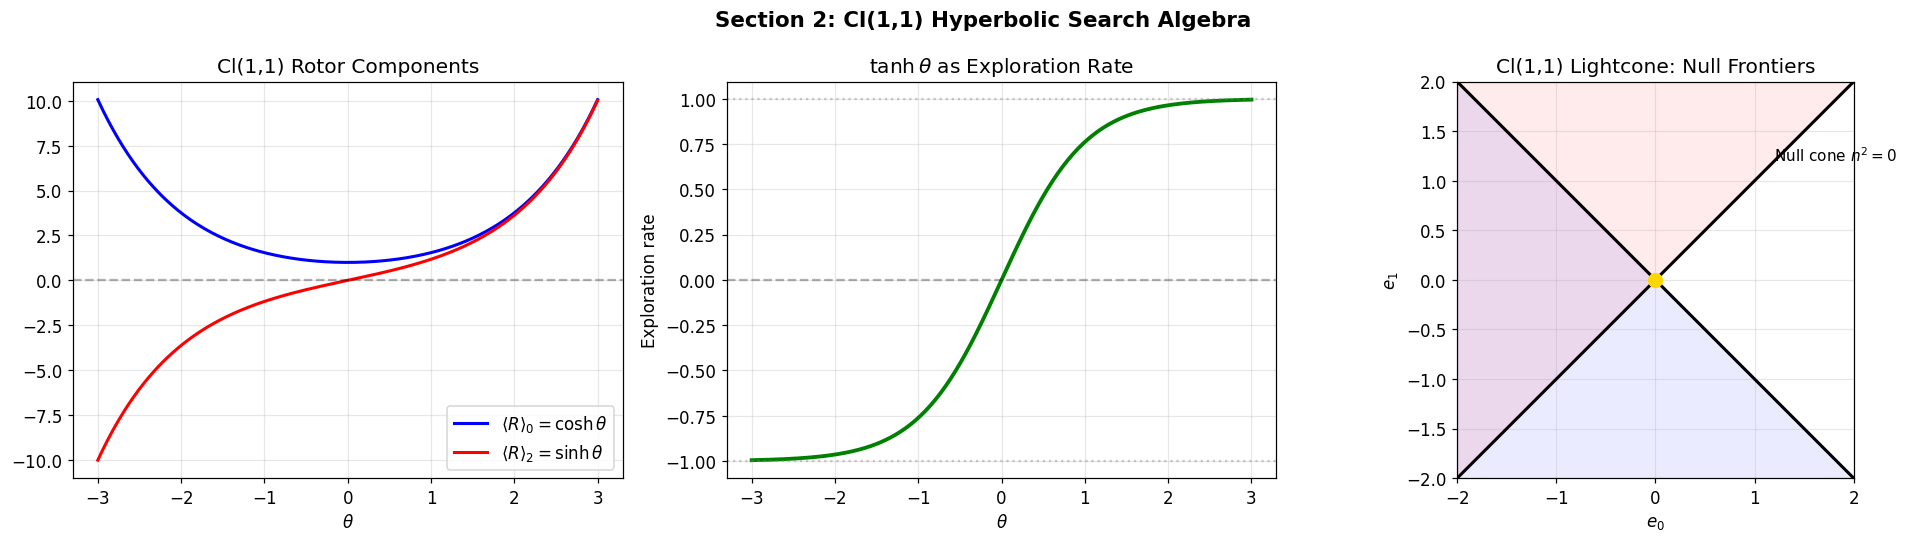

Null vectors: n = e_0 +/- e_1,  n^2 = 1 - 1 = 0
=> Simultaneous frontier projection without metric interference


In [4]:
thetas = np.linspace(-3, 3, 300)
bvec = torch.zeros(len(thetas), alg11.dim)
bvec[:, 3] = torch.tensor(thetas, dtype=torch.float32)  # e_{01}
rotors = alg11.exp(bvec)

R0 = rotors[:, 0].numpy()  # cosh(theta)
R2 = rotors[:, 3].numpy()  # sinh(theta)
explore_rate = R2 / R0      # tanh(theta)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(thetas, R0, 'b-', lw=2, label=r'$\langle R\rangle_0=\cosh\theta$')
axes[0].plot(thetas, R2, 'r-', lw=2, label=r'$\langle R\rangle_2=\sinh\theta$')
axes[0].axhline(0, color='k', ls='--', alpha=.3)
axes[0].set_xlabel(r'$\theta$'); axes[0].set_title('Cl(1,1) Rotor Components')
axes[0].legend(); axes[0].grid(True, alpha=.3)

axes[1].plot(thetas, explore_rate, 'g-', lw=2.5)
axes[1].axhline(0, color='k', ls='--', alpha=.3)
axes[1].axhline(1, color='gray', ls=':', alpha=.4); axes[1].axhline(-1, color='gray', ls=':', alpha=.4)
axes[1].set_xlabel(r'$\theta$'); axes[1].set_ylabel('Exploration rate')
axes[1].set_title(r'$\tanh\theta$ as Exploration Rate'); axes[1].grid(True, alpha=.3)

t = np.linspace(-2, 2, 300)
axes[2].fill_between(t, t, 2.5, alpha=.08, color='red')
axes[2].fill_between(t, -2.5, -t, alpha=.08, color='blue')
axes[2].plot(t, t, 'k-', lw=2); axes[2].plot(t, -t, 'k-', lw=2)
axes[2].scatter([0], [0], s=80, c='gold', zorder=5)
axes[2].annotate('Null cone $n^2=0$', xy=(1.2, 1.2), fontsize=10)
axes[2].set_xlim(-2, 2); axes[2].set_ylim(-2, 2)
axes[2].set_xlabel(r'$e_0$'); axes[2].set_ylabel(r'$e_1$')
axes[2].set_title('Cl(1,1) Lightcone: Null Frontiers')
axes[2].set_aspect('equal'); axes[2].grid(True, alpha=.3)

plt.suptitle('Section 2: Cl(1,1) Hyperbolic Search Algebra', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('Null vectors: n = e_0 +/- e_1,  n^2 = 1 - 1 = 0')
print('=> Simultaneous frontier projection without metric interference')

### Proposition 2: Hyperbolic Volume Growth Matches Search Branching

**Claim**: $\tanh\theta$ from Cl(1,1) is geometrically natural for tree search.

**Proof sketch**:

1. **Hyperbolic area**: In the Poincar\'{e} disk (embedded in Cl(1,1)): $A(r) = 4\pi\sinh^2(r/2) \sim \pi e^r$

2. **Search tree**: Branching factor $b$ gives $\sim b^d$ nodes at depth $d$.

3. **Isometry**: Setting $b^d = e^r$ gives $r = d\ln b$ — hyperbolic radius scales **linearly** with search depth. The tree embeds naturally into hyperbolic space.

4. **Velocity addition law**: $\tanh$ satisfies the **relativistic composition**:
$$\tanh(\alpha + \beta) = \frac{\tanh\alpha + \tanh\beta}{1 + \tanh\alpha\cdot\tanh\beta}$$
   Composing two exploration steps always stays bounded — a **structural regularization** absent in UCB's $\sqrt{\log N/n}$ (which can exceed 1).

5. **GSS mapping**: Set $\theta = c/\sqrt{n}$. Then $\tanh(c/\sqrt{n}) = O(1/\sqrt{n})$ for large $n$, matching the optimal exploration decay, while being bounded in $(-1,1)$ for all $n \geq 1$.

---

**Null vector frontier** *(future work)*: In Cl(1,1), null vectors $n^2 = 0$ lie on the lightcone boundary between timelike (explored, $n^2 > 0$) and spacelike (unexplored, $n^2 < 0$). Projecting hypotheses onto null directions enables **simultaneous frontier expansion** without metric interference — the geometric analogue of parallel search.

### Proposition 3: Null Vectors as Exploration Boundary

**Claim**: In Cl(1,1), null vectors ($h^2 = 0$) form a natural causal boundary between explored and unexplored hypothesis regions.

**Setup**: Consider a hypothesis multivector $h = a\,e_+ + b\,e_-$ in Cl(1,1), where $e_+^2 = +1$ and $e_-^2 = -1$. The squared norm is:

$$\|h\|^2 = \langle h \tilde{h} \rangle_0 = a^2 - b^2$$

Define the **causal classifier**:

$$\text{classify}(h) = \text{sign}(\|h\|^2) = \begin{cases} +1 & \text{(timelike: } |a| > |b|\text{, explored)} \\ 0 & \text{(null: } |a| = |b|\text{, frontier)} \\ -1 & \text{(spacelike: } |a| < |b|\text{, unexplored)} \end{cases}$$

**Interpretation for GSS**:
- **Timelike** ($h^2 > 0$): The exploitation component $a$ (accumulated value) dominates the exploration component $b$ (uncertainty). This hypothesis is well-explored.
- **Spacelike** ($h^2 < 0$): Uncertainty dominates value — the hypothesis is in unexplored territory.
- **Null** ($h^2 = 0$): The lightcone boundary where exploitation and exploration are balanced. This is the natural **frontier** for beam expansion.

**Frontier expansion trigger**: When a hypothesis drifts toward the null boundary ($|h^2| < \epsilon$), it signals a transition point. The log-manifold manager can use this as a cue to allocate new beam hypotheses — expanding the search frontier precisely where the exploration-exploitation balance is sharpest.

---

**Conjecture** *(open)*: GSS exploration along null geodesics avoids metric interference between simultaneous search frontiers, enabling parallel frontier expansion without cross-contamination of exploration signals. The null condition $h^2 = 0$ acts as an orthogonality constraint in the indefinite metric of Cl(1,1).

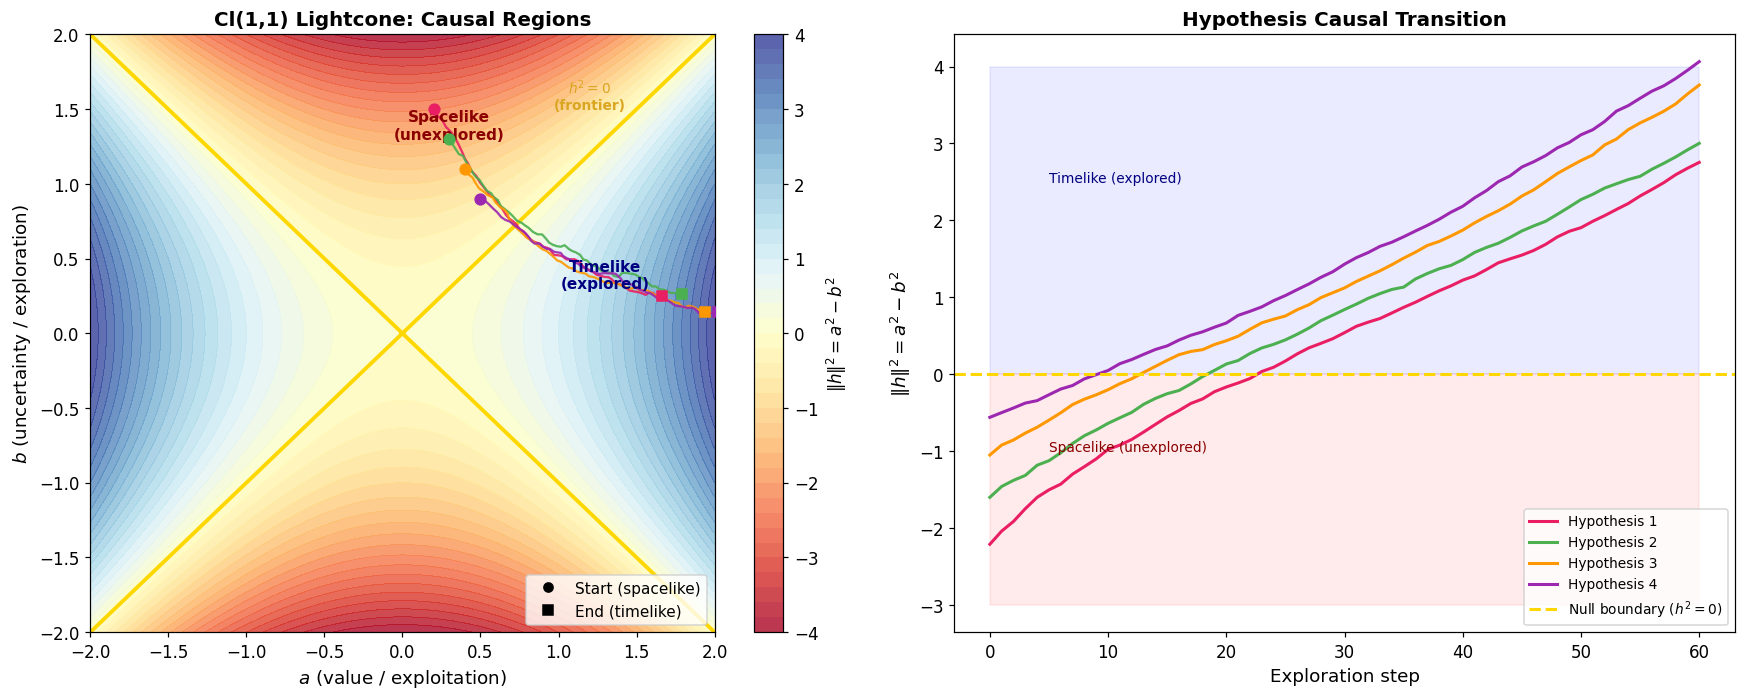

Cl(1,1) verification: h = 1.2 e+ + 0.8 e-
  norm_sq = 0.8000  (expected: 1.2²-0.8² = 0.8000)
  classify: timelike


In [5]:
# Lightcone visualization: causal regions in Cl(1,1)

def causal_classify(a_vals, b_vals):
    """Classify (a, b) pairs by sign of a^2 - b^2 in Cl(1,1)."""
    return np.sign(a_vals**2 - b_vals**2)

# --- Panel 1: Lightcone diagram ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Grid over (a, b) parameter space
res = 300
a_range = np.linspace(-2, 2, res)
b_range = np.linspace(-2, 2, res)
A, B_grid = np.meshgrid(a_range, b_range)
norm_sq = A**2 - B_grid**2

ax = axes[0]
cmap = plt.cm.RdYlBu
im = ax.contourf(A, B_grid, norm_sq, levels=50, cmap=cmap, alpha=0.8)
ax.contour(A, B_grid, norm_sq, levels=[0], colors='gold', linewidths=2.5)
plt.colorbar(im, ax=ax, label=r'$\|h\|^2 = a^2 - b^2$')

# Simulate hypothesis trajectories: start spacelike, drift toward timelike
torch.manual_seed(123)
n_traj = 4
traj_colors = ['#E91E63', '#4CAF50', '#FF9800', '#9C27B0']
for k in range(n_traj):
    # Start with |b| > |a| (spacelike)
    a_t, b_t = 0.2 + 0.1 * k, 1.5 - 0.2 * k
    traj_a, traj_b = [a_t], [b_t]
    for step in range(60):
        # a grows (value accumulation), b decays (uncertainty reduction)
        a_t += 0.025 + 0.005 * np.random.randn()
        b_t *= 0.97
        b_t += 0.01 * np.random.randn()
        traj_a.append(a_t); traj_b.append(b_t)
    traj_a, traj_b = np.array(traj_a), np.array(traj_b)
    ax.plot(traj_a, traj_b, '-', color=traj_colors[k], lw=1.5, alpha=0.9)
    ax.plot(traj_a[0], traj_b[0], 'o', color=traj_colors[k], ms=7, zorder=5)
    ax.plot(traj_a[-1], traj_b[-1], 's', color=traj_colors[k], ms=7, zorder=5)

ax.plot([], [], 'ko', ms=6, label='Start (spacelike)')
ax.plot([], [], 'ks', ms=6, label='End (timelike)')
ax.set_xlabel(r'$a$ (value / exploitation)', fontsize=12)
ax.set_ylabel(r'$b$ (uncertainty / exploration)', fontsize=12)
ax.set_title('Cl(1,1) Lightcone: Causal Regions', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.text(1.3, 0.3, 'Timelike\n(explored)', ha='center', fontsize=10, color='navy', fontweight='bold')
ax.text(0.3, 1.3, 'Spacelike\n(unexplored)', ha='center', fontsize=10, color='darkred', fontweight='bold')
ax.text(1.2, 1.5, r'$h^2=0$'+'\n(frontier)', ha='center', fontsize=9, color='goldenrod', fontweight='bold')

# --- Panel 2: norm_sq over time for each trajectory ---
ax2 = axes[1]
torch.manual_seed(123)
for k in range(n_traj):
    a_t, b_t = 0.2 + 0.1 * k, 1.5 - 0.2 * k
    nsq_vals = [a_t**2 - b_t**2]
    for step in range(60):
        a_t += 0.025 + 0.005 * np.random.randn()
        b_t *= 0.97; b_t += 0.01 * np.random.randn()
        nsq_vals.append(a_t**2 - b_t**2)
    ax2.plot(nsq_vals, color=traj_colors[k], lw=2, label=f'Hypothesis {k+1}')

ax2.axhline(0, color='gold', lw=2, ls='--', label=r'Null boundary ($h^2=0$)')
ax2.fill_between(range(61), -3, 0, alpha=0.08, color='red')
ax2.fill_between(range(61), 0, 4, alpha=0.08, color='blue')
ax2.set_xlabel('Exploration step', fontsize=12)
ax2.set_ylabel(r'$\|h\|^2 = a^2 - b^2$', fontsize=12)
ax2.set_title('Hypothesis Causal Transition', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')
ax2.text(5, -1.0, 'Spacelike (unexplored)', fontsize=9, color='darkred')
ax2.text(5, 2.5, 'Timelike (explored)', fontsize=9, color='navy')

plt.tight_layout()
plt.show()

# Verify with actual Cl(1,1) norm_sq
test_mv = torch.zeros(alg11.dim)
test_mv[1] = 1.2   # e+ component (grade-1, index 1)
test_mv[2] = 0.8   # e- component (grade-1, index 2)
nsq = alg11.norm_sq(test_mv)
print(f'Cl(1,1) verification: h = 1.2 e+ + 0.8 e-')
print(f'  norm_sq = {nsq.item():.4f}  (expected: 1.2²-0.8² = {1.2**2 - 0.8**2:.4f})')
print(f'  classify: {"timelike" if nsq > 0 else "null" if nsq == 0 else "spacelike"}')

## Section 3 -- GSS Core Algorithm

```
GSS(env):
  for each step:
    1. Embed state as grade-1 mv in Cl(3,0)
    2. For each action a with predicted next-state s':
       - relational uncertainty = ||grade-2(GP(mv_s, mv_s'))||
       - score = Q[s,a] + tanh(c / sqrt(N[s,a])) * relational_uncertainty
    3. Entropy gate beam of action-mvs, suppress disordered hypotheses
    4. Select argmax action
```

Key: the bivector norm of the geometric product measures *angular* uncertainty between current and predicted next state.

In [6]:
# ---- Helper: relational bivector norm between two multivectors ----
def relational_bv_norm(mv_a, mv_b, alg=alg30):
    """||grade-2(GP(a, b))||  --  measures angular uncertainty."""
    gp = alg.geometric_product(mv_a.unsqueeze(0), mv_b.unsqueeze(0)).squeeze(0)
    return alg.grade_projection(gp, 2).norm().item()


class GSSAgent:
    """GSS agent for bandit. Arms on unit circle + bivector uncertainty."""
    def __init__(self, n_actions, c_explore=1.0):
        self.n_actions = n_actions
        self.c = c_explore
        self.Q = np.zeros(n_actions)
        self.N = np.zeros(n_actions, dtype=int)
        self.t = 0
        # Arms on unit circle in grade-1 subspace
        angles = torch.linspace(0, 2 * math.pi, n_actions + 1)[:-1]
        vecs = torch.stack([torch.cos(angles), torch.sin(angles),
                            torch.zeros(n_actions)], dim=1)
        self.action_mvs = alg30.embed_vector(vecs)  # [K, 8]
        # Reference mv for relational uncertainty
        ref = torch.zeros(3); ref[2] = 1.0
        self.ref_mv = alg30.embed_vector(ref.unsqueeze(0)).squeeze(0)
        # Entropy gated attention
        self.ega = EntropyGatedAttention(alg30, channels=1, num_heads=1,
                                         eta=1.0, H_base=0.5)
        self.ega.eval()
        self.log = {'H': [], 'lam': [], 'grades': []}
        # Initialize bivector uncertainty (non-zero grade-2 for entropy dynamics)
        bv_idx = alg30.grade_masks[2].nonzero(as_tuple=False).squeeze(-1)
        self._bv_idx = bv_idx
        for a in range(n_actions):
            ang = 2 * math.pi * a / n_actions
            self.action_mvs[a, bv_idx[0]] = 0.5
            self.action_mvs[a, bv_idx[1]] = 0.3 * math.sin(ang)
            self.action_mvs[a, bv_idx[2]] = 0.3 * math.cos(ang)
        self._init_bv = self.action_mvs[:, bv_idx].clone()

    def select_action(self):
        if self.t < self.n_actions:
            return self.t
        beam = self.action_mvs.unsqueeze(0).unsqueeze(2)  # [1,K,1,8]
        with torch.no_grad():
            _, H, lam = self.ega(beam, return_gating=True)
        self.log['H'].append(H.item())
        self.log['lam'].append(lam.item())
        self.log['grades'].append(alg30.get_grade_norms(self.action_mvs).mean(0).numpy().copy())
        scores = np.array([
            self.Q[a] + math.tanh(self.c / math.sqrt(max(1, self.N[a])))
            * relational_bv_norm(self.action_mvs[a], self.ref_mv)
            for a in range(self.n_actions)])
        return int(np.argmax(scores))

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]
        # Grade-aware mv update: G0 tracks value, G2 decays with visits
        mv = self.action_mvs[action].clone()
        mv[0] = self.Q[action]                             # grade-0 = estimated value
        unc = 1.0 / math.sqrt(self.N[action])
        mv[self._bv_idx] = self._init_bv[action] * unc     # grade-2 decays as 1/sqrt(N)
        self.action_mvs[action] = mv
        self.t += 1


class UCTAgent:
    """UCB/UCT baseline."""
    def __init__(self, n_actions, c=math.sqrt(2)):
        self.n_actions = n_actions; self.c = c
        self.Q = np.zeros(n_actions); self.N = np.zeros(n_actions, dtype=int)
        self.t = 0
    def select_action(self):
        if self.t < self.n_actions: return self.t
        return int(np.argmax(self.Q + self.c * np.sqrt(np.log(self.t) / (self.N + 1e-8))))
    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]
        self.t += 1


print('GSSAgent (with grade-aware dynamics) and UCTAgent defined.')

GSSAgent (with grade-aware dynamics) and UCTAgent defined.


## Section 4a -- 10-Armed Bandit

In [7]:
def run_bandit(n_arms=10, n_rounds=1000, n_seeds=20):
    results = {name: [] for name in ('gss', 'uct')}
    for seed in range(n_seeds):
        rng = np.random.RandomState(seed)
        mu = rng.uniform(-1, 1, n_arms)
        mu_star = mu.max()
        agents = {'gss': GSSAgent(n_arms, c_explore=1.0), 'uct': UCTAgent(n_arms)}
        cum = {k: 0.0 for k in agents}
        traces = {k: [] for k in agents}
        for t in range(n_rounds):
            for name, ag in agents.items():
                a = ag.select_action()
                r = rng.normal(mu[a], 1.0)
                ag.update(a, r)
                cum[name] += mu_star - mu[a]
                traces[name].append(cum[name])
        for name in agents:
            results[name].append(traces[name])
    return results

print('Running 10-armed bandit (20 seeds x 1000 rounds)...')
bandit_res = run_bandit()
print('Done.')

Running 10-armed bandit (20 seeds x 1000 rounds)...
Done.


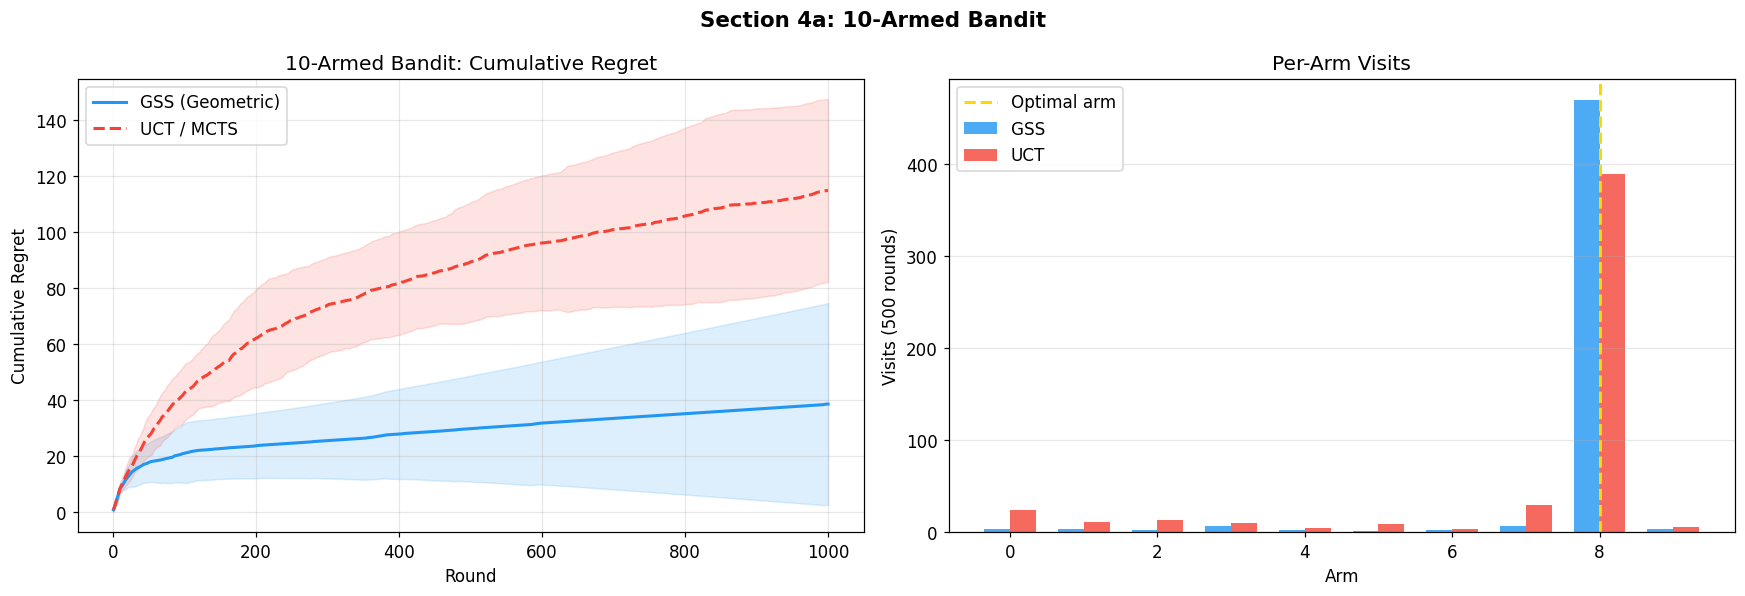

In [8]:
styles = {'gss': ('GSS (Geometric)', '#2196F3', '-'),
          'uct': ('UCT / MCTS', '#F44336', '--')}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
rounds = np.arange(1, 1001)
for name, (label, color, ls) in styles.items():
    d = np.array(bandit_res[name])
    m, s = d.mean(0), d.std(0)
    axes[0].plot(rounds, m, color=color, ls=ls, lw=2, label=label)
    axes[0].fill_between(rounds, m - s, m + s, color=color, alpha=.15)
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Cumulative Regret')
axes[0].set_title('10-Armed Bandit: Cumulative Regret'); axes[0].legend(); axes[0].grid(True, alpha=.3)

# Single-run arm visits
rng = np.random.RandomState(0); mu = rng.uniform(-1, 1, 10)
agv = {'gss': GSSAgent(10), 'uct': UCTAgent(10)}
for _ in range(500):
    for ag in agv.values():
        a = ag.select_action(); ag.update(a, rng.normal(mu[a], 1.0))

arms = np.arange(10); w = 0.35
axes[1].bar(arms - w/2, agv['gss'].N, w, label='GSS', color='#2196F3', alpha=.8)
axes[1].bar(arms + w/2, agv['uct'].N, w, label='UCT', color='#F44336', alpha=.8)
axes[1].axvline(int(np.argmax(mu)), color='gold', ls='--', lw=2, label='Optimal arm')
axes[1].set_xlabel('Arm'); axes[1].set_ylabel('Visits (500 rounds)')
axes[1].set_title('Per-Arm Visits'); axes[1].legend(); axes[1].grid(True, alpha=.3, axis='y')

plt.suptitle('Section 4a: 10-Armed Bandit', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

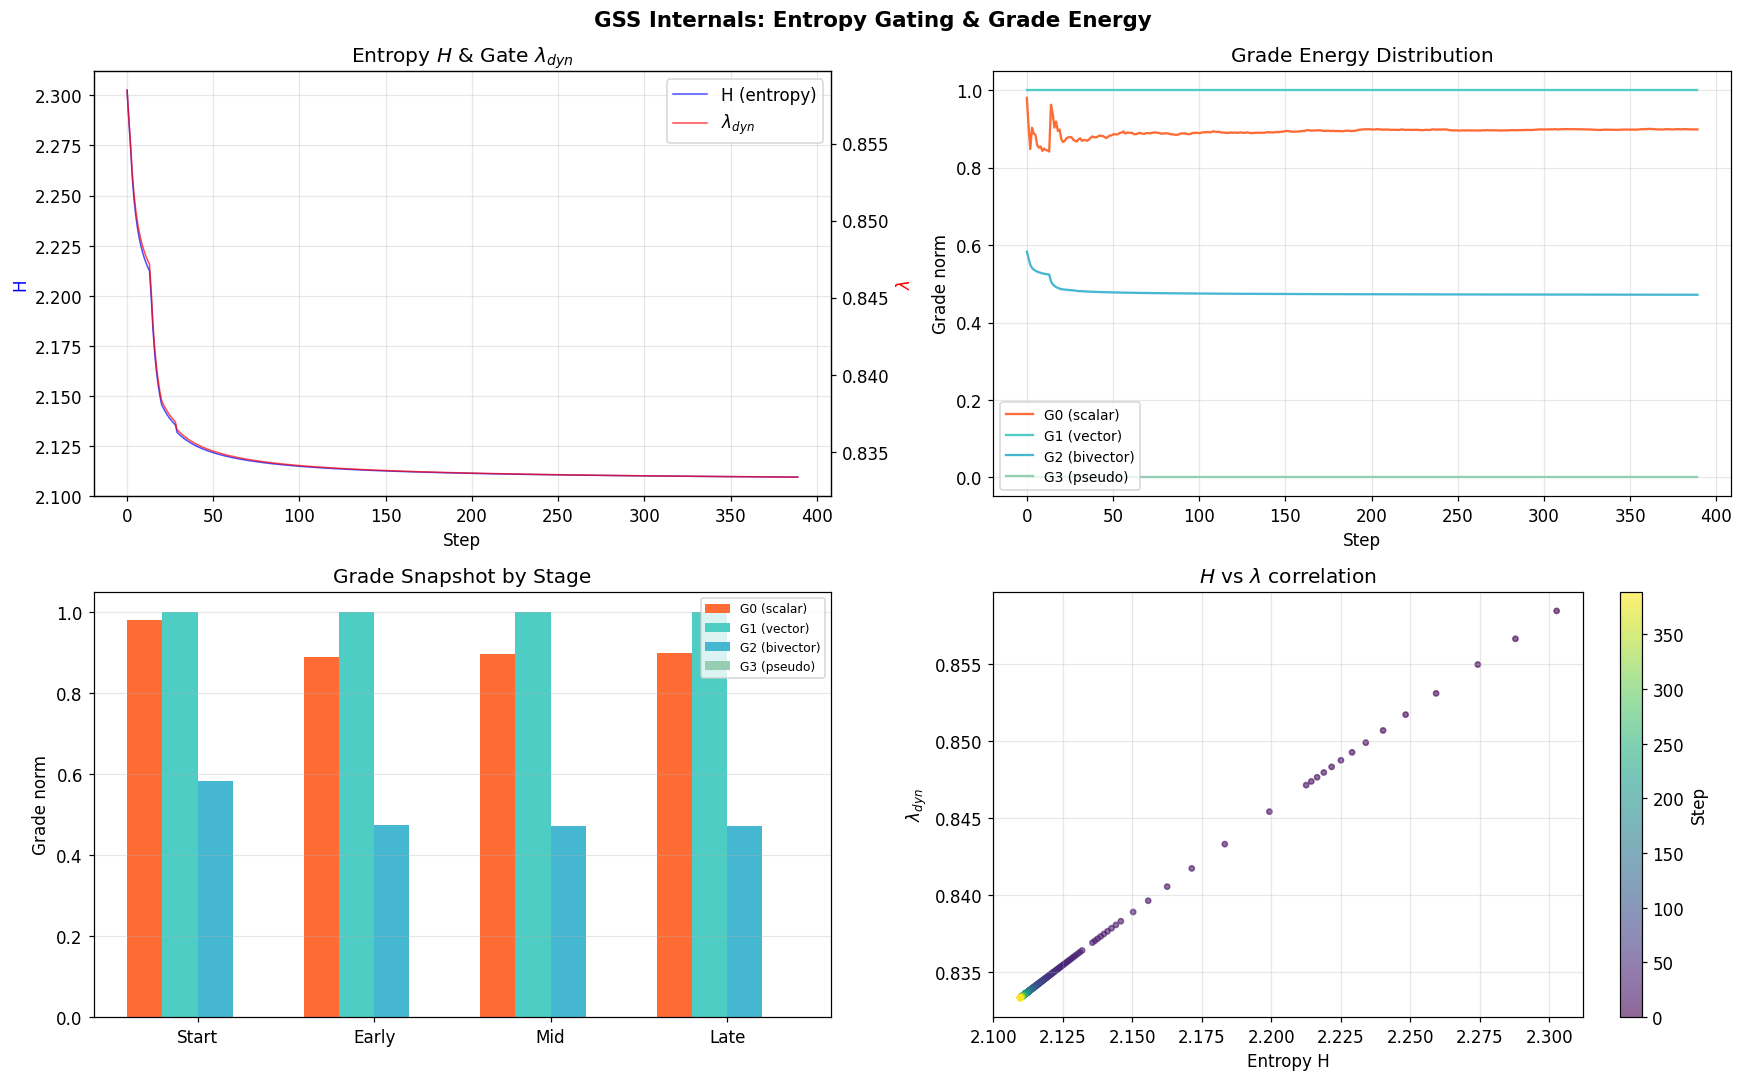

In [9]:
# GSS diagnostics: entropy gating & grade energy
rng = np.random.RandomState(42); mu = rng.uniform(-1, 1, 10)
diag = GSSAgent(10, c_explore=1.0)
for _ in range(400):
    a = diag.select_action(); diag.update(a, rng.normal(mu[a], 1.0))

H_v = np.array(diag.log['H']); lam_v = np.array(diag.log['lam'])
grades = np.array(diag.log['grades']); T = np.arange(len(H_v))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax, ax2 = axes[0, 0], axes[0, 0].twinx()
l1, = ax.plot(T, H_v, 'b-', lw=1, alpha=.7, label='H (entropy)')
l2, = ax2.plot(T, lam_v, 'r-', lw=1, alpha=.7, label=r'$\lambda_{dyn}$')
ax.set_xlabel('Step'); ax.set_ylabel('H', color='b'); ax2.set_ylabel(r'$\lambda$', color='r')
ax.set_title(r'Entropy $H$ & Gate $\lambda_{dyn}$'); ax.legend(handles=[l1, l2]); ax.grid(True, alpha=.3)

gn = ['G0 (scalar)', 'G1 (vector)', 'G2 (bivector)', 'G3 (pseudo)']
gc = ['#FF6B35', '#4ECDC4', '#45B7D1', '#96CEB4']
for k in range(4):
    axes[0, 1].plot(T, grades[:, k], color=gc[k], lw=1.5, label=gn[k])
axes[0, 1].set_xlabel('Step'); axes[0, 1].set_ylabel('Grade norm')
axes[0, 1].set_title('Grade Energy Distribution'); axes[0, 1].legend(fontsize=9); axes[0, 1].grid(True, alpha=.3)

stages = [0, len(T)//3, 2*len(T)//3, len(T)-1]; slbl = ['Start', 'Early', 'Mid', 'Late']; w = 0.2
for k in range(4):
    axes[1, 0].bar(np.arange(4) + k*w, [grades[s, k] for s in stages], w, color=gc[k], label=gn[k])
axes[1, 0].set_xticks(np.arange(4)+0.3); axes[1, 0].set_xticklabels(slbl)
axes[1, 0].set_ylabel('Grade norm'); axes[1, 0].set_title('Grade Snapshot by Stage')
axes[1, 0].legend(fontsize=8); axes[1, 0].grid(True, alpha=.3, axis='y')

sc = axes[1, 1].scatter(H_v, lam_v, c=T, cmap='viridis', s=12, alpha=.6)
plt.colorbar(sc, ax=axes[1, 1], label='Step')
axes[1, 1].set_xlabel('Entropy H'); axes[1, 1].set_ylabel(r'$\lambda_{dyn}$')
axes[1, 1].set_title(r'$H$ vs $\lambda$ correlation'); axes[1, 1].grid(True, alpha=.3)

plt.suptitle('GSS Internals: Entropy Gating & Grade Energy', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Running exploration function comparison (20 seeds x 1000 rounds)...
Done.


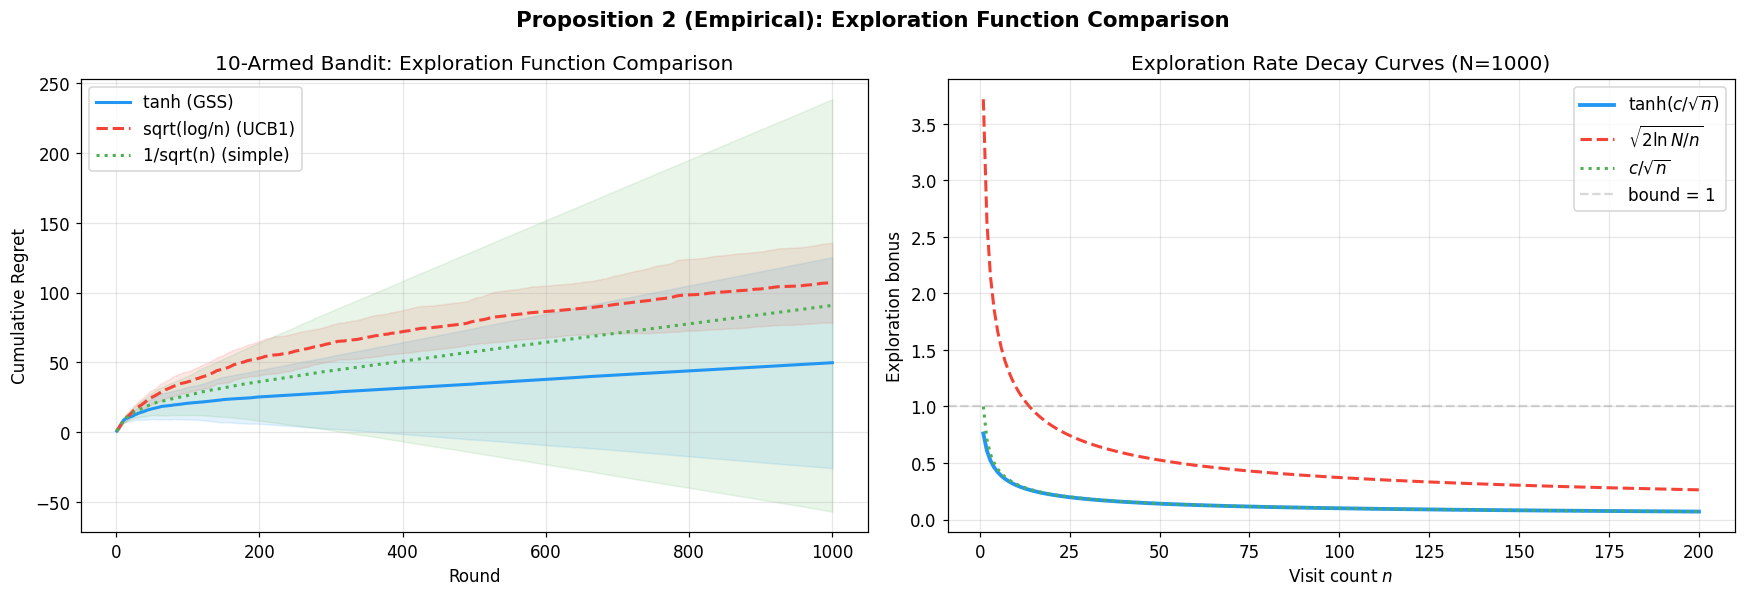


Final regret (mean over 20 seeds):
  tanh (GSS)               : 49.8
  sqrt(log/n) (UCB1)       : 107.1
  1/sqrt(n) (simple)       : 90.9


In [10]:
# Empirical: compare 3 exploration functions on the same Q-learning backbone
class ExploreAgent:
    """Generic agent with pluggable exploration function."""
    def __init__(self, n_actions, explore_fn, label):
        self.n_actions = n_actions; self.label = label
        self.Q = np.zeros(n_actions); self.N = np.zeros(n_actions, dtype=int)
        self.t = 0; self._explore_fn = explore_fn
    def select_action(self):
        if self.t < self.n_actions: return self.t
        bonus = np.array([self._explore_fn(self.N[a], self.t) for a in range(self.n_actions)])
        return int(np.argmax(self.Q + bonus))
    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]
        self.t += 1

def tanh_explore(n, t, c=1.0): return math.tanh(c / math.sqrt(max(1, n)))
def ucb_explore(n, t, c=math.sqrt(2)): return c * math.sqrt(math.log(max(2, t)) / max(1, n))
def simple_explore(n, t, c=1.0): return c / math.sqrt(max(1, n))

def run_compare(n_arms=10, n_rounds=1000, n_seeds=20):
    labels = ['tanh (GSS)', 'sqrt(log/n) (UCB1)', '1/sqrt(n) (simple)']
    fns = [tanh_explore, ucb_explore, simple_explore]
    results = {l: [] for l in labels}
    for seed in range(n_seeds):
        rng = np.random.RandomState(seed)
        mu = rng.uniform(-1, 1, n_arms); mu_star = mu.max()
        agents = {l: ExploreAgent(n_arms, f, l) for l, f in zip(labels, fns)}
        cum = {l: 0.0 for l in labels}; traces = {l: [] for l in labels}
        for t in range(n_rounds):
            for l, ag in agents.items():
                a = ag.select_action(); r = rng.normal(mu[a], 1.0)
                ag.update(a, r); cum[l] += mu_star - mu[a]; traces[l].append(cum[l])
        for l in labels: results[l].append(traces[l])
    return results, labels

print('Running exploration function comparison (20 seeds x 1000 rounds)...')
cmp_res, cmp_labels = run_compare()
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
colors3 = ['#2196F3', '#F44336', '#4CAF50']
ls3 = ['-', '--', ':']
rounds = np.arange(1, 1001)
for i, l in enumerate(cmp_labels):
    d = np.array(cmp_res[l]); m = d.mean(0); s = d.std(0)
    axes[0].plot(rounds, m, color=colors3[i], ls=ls3[i], lw=2, label=l)
    axes[0].fill_between(rounds, m - s, m + s, color=colors3[i], alpha=.12)
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Cumulative Regret')
axes[0].set_title('10-Armed Bandit: Exploration Function Comparison')
axes[0].legend(); axes[0].grid(True, alpha=.3)

n_arr = np.arange(1, 201)
axes[1].plot(n_arr, [tanh_explore(n, 1000) for n in n_arr], color=colors3[0], lw=2.5, label=r'$\tanh(c/\sqrt{n})$')
axes[1].plot(n_arr, [ucb_explore(n, 1000) for n in n_arr], color=colors3[1], ls='--', lw=2, label=r'$\sqrt{2\ln N/n}$')
axes[1].plot(n_arr, [simple_explore(n, 1000) for n in n_arr], color=colors3[2], ls=':', lw=2, label=r'$c/\sqrt{n}$')
axes[1].axhline(1, color='gray', ls='--', alpha=.3, label='bound = 1')
axes[1].set_xlabel('Visit count $n$'); axes[1].set_ylabel('Exploration bonus')
axes[1].set_title('Exploration Rate Decay Curves (N=1000)')
axes[1].legend(); axes[1].grid(True, alpha=.3)

plt.suptitle('Proposition 2 (Empirical): Exploration Function Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nFinal regret (mean over {20} seeds):')
for l in cmp_labels:
    print(f'  {l:<25s}: {np.array(cmp_res[l])[:, -1].mean():.1f}')

## Section 4b -- Chain MDP

States $\{0, \ldots, N{-}1\}$, actions $\{\text{left}, \text{right}\}$, reward $+1$ at state $N{-}1$.

States embedded on a **semicircle** in Cl(3,0) so adjacent states have non-zero angular separation and therefore non-zero bivector exploration signal.

In [11]:
class ChainMDP:
    def __init__(self, n=8): self.n = n; self.state = 0
    def reset(self): self.state = 0; return self.state
    def step(self, a):
        if a == 1: self.state = min(self.state + 1, self.n - 1)
        else:      self.state = max(self.state - 1, 0)
        r = 1.0 if self.state == self.n - 1 else 0.0
        return self.state, r, self.state == self.n - 1


def _embed_chain_states(n_states):
    """Embed chain states on semicircle for non-trivial bivector norms."""
    angles = torch.linspace(0, math.pi, n_states)
    vecs = torch.stack([torch.cos(angles), torch.sin(angles),
                        torch.zeros(n_states)], dim=1)
    return alg30.embed_vector(vecs)  # [S, 8]


class GSSChainAgent:
    """GSS agent for chain MDP. Explores via relational bivector norm."""
    def __init__(self, n_states, c=1.0):
        self.ns = n_states; self.na = 2; self.c = c
        self.Q = np.zeros((n_states, 2))
        self.N = np.zeros((n_states, 2), dtype=int)
        self.state_mvs = _embed_chain_states(n_states)
        self.gamma = 0.99

    def _next_state(self, s, a):
        return min(s + 1, self.ns - 1) if a == 1 else max(s - 1, 0)

    def select_action(self, s):
        scores = []
        for a in range(self.na):
            n = max(1, self.N[s, a])
            s2 = self._next_state(s, a)
            bv = relational_bv_norm(self.state_mvs[s], self.state_mvs[s2])
            explore = math.tanh(self.c / math.sqrt(n)) * bv
            scores.append(self.Q[s, a] + explore)
        return int(np.argmax(scores))

    def update(self, s, a, r, s2, done):
        self.N[s, a] += 1
        lr = 1.0 / self.N[s, a]
        target = r + (0.0 if done else self.gamma * self.Q[s2].max())
        self.Q[s, a] += lr * (target - self.Q[s, a])


class UCTChainAgent:
    def __init__(self, n_states, c=math.sqrt(2)):
        self.ns = n_states; self.na = 2; self.c_uct = c
        self.Q = np.zeros((n_states, 2))
        self.N = np.zeros((n_states, 2), dtype=int)
        self.Ns = np.zeros(n_states, dtype=int)
        self.gamma = 0.99

    def select_action(self, s):
        self.Ns[s] += 1
        if self.Ns[s] <= self.na: return (self.Ns[s] - 1) % self.na
        ucb = self.Q[s] + self.c_uct * np.sqrt(np.log(self.Ns[s]) / (self.N[s] + 1e-8))
        return int(np.argmax(ucb))

    def update(self, s, a, r, s2, done):
        self.N[s, a] += 1
        lr = 1.0 / self.N[s, a]
        target = r + (0.0 if done else self.gamma * self.Q[s2].max())
        self.Q[s, a] += lr * (target - self.Q[s, a])


def run_chain(n_states=8, n_episodes=300, max_steps=50, n_seeds=10):
    results = {n: [] for n in ('gss', 'uct')}
    value_est = {n: [] for n in ('gss', 'uct')}
    visit_maps = {n: [] for n in ('gss', 'uct')}
    for seed in range(n_seeds):
        np.random.seed(seed); torch.manual_seed(seed)
        env = ChainMDP(n_states)
        agents = {'gss': GSSChainAgent(n_states), 'uct': UCTChainAgent(n_states)}
        ep_rew = {k: [] for k in agents}
        for ep in range(n_episodes):
            for name, ag in agents.items():
                s = env.reset(); tot = 0.0
                for _ in range(max_steps):
                    a = ag.select_action(s)
                    s2, r, done = env.step(a)
                    ag.update(s, a, r, s2, done)
                    s = s2; tot += r
                    if done: break
                ep_rew[name].append(tot)
        for name, ag in agents.items():
            results[name].append(ep_rew[name])
            value_est[name].append(ag.Q.max(axis=1).copy())
            visit_maps[name].append(ag.N.sum(axis=1).copy())
    return results, value_est, visit_maps

print('Running Chain MDP (10 seeds x 300 episodes)...')
chain_res, chain_vals, chain_visits = run_chain()
print('Done.')

Running Chain MDP (10 seeds x 300 episodes)...
Done.


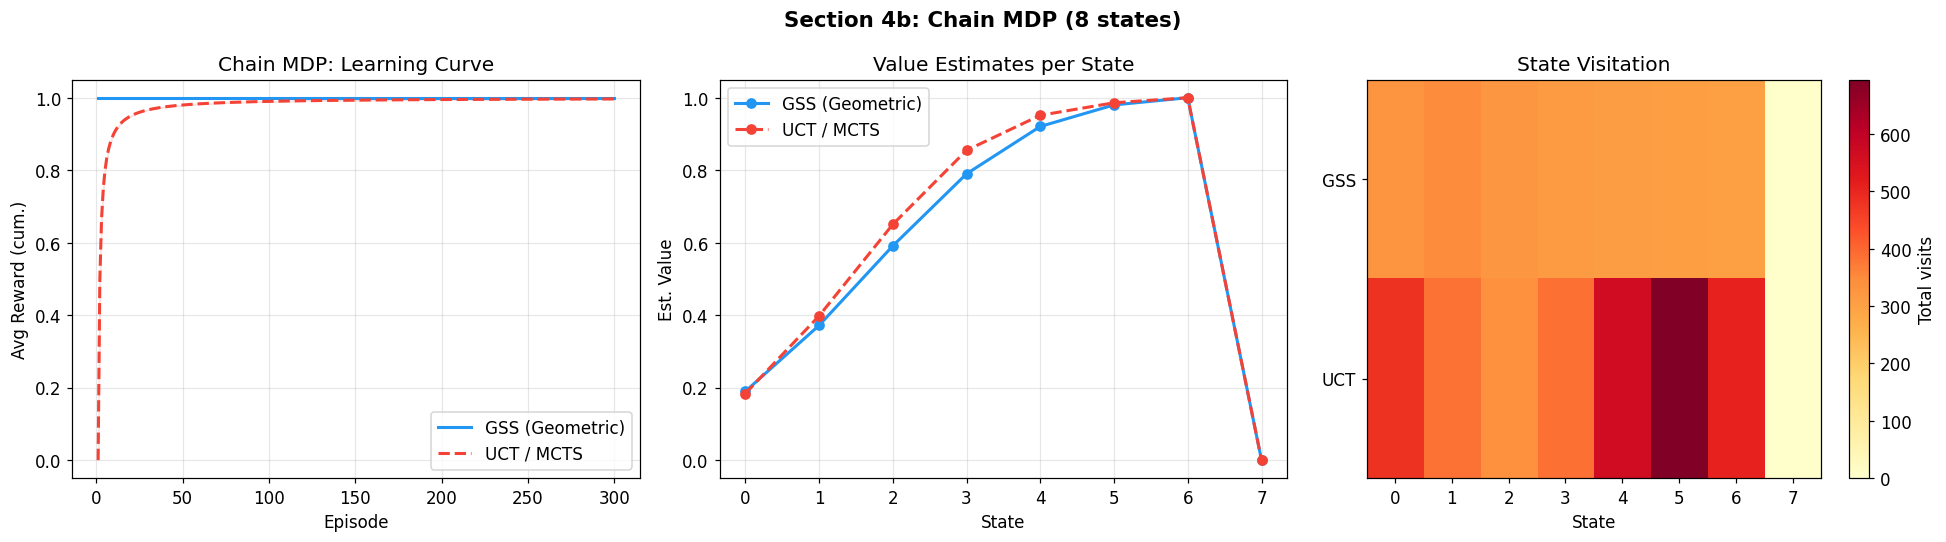

Bivector norms between adjacent chain states (semicircle embedding):
  state 0 <-> 1: ||B|| = 0.4339
  state 1 <-> 2: ||B|| = 0.4339
  state 2 <-> 3: ||B|| = 0.4339
  state 3 <-> 4: ||B|| = 0.4339
  state 4 <-> 5: ||B|| = 0.4339
  state 5 <-> 6: ||B|| = 0.4339
  state 6 <-> 7: ||B|| = 0.4339


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
eps = np.arange(1, 301)

for name, (label, color, ls) in styles.items():
    d = np.array(chain_res[name])
    sm = np.cumsum(d, axis=1) / np.arange(1, d.shape[1]+1)
    m, s = sm.mean(0), sm.std(0)
    axes[0].plot(eps, m, color=color, ls=ls, lw=2, label=label)
    axes[0].fill_between(eps, m - s, m + s, color=color, alpha=.15)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Avg Reward (cum.)')
axes[0].set_title('Chain MDP: Learning Curve'); axes[0].legend(); axes[0].grid(True, alpha=.3)

states = np.arange(8)
for name, (label, color, ls) in styles.items():
    axes[1].plot(states, np.array(chain_vals[name]).mean(0), color=color, marker='o', ls=ls, lw=2, label=label)
axes[1].set_xlabel('State'); axes[1].set_ylabel('Est. Value')
axes[1].set_title('Value Estimates per State'); axes[1].legend(); axes[1].grid(True, alpha=.3)

vd = np.array([np.array(chain_visits['gss']).mean(0), np.array(chain_visits['uct']).mean(0)])
im = axes[2].imshow(vd, cmap='YlOrRd', aspect='auto')
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(['GSS', 'UCT'])
axes[2].set_xticks(states); axes[2].set_xlabel('State')
axes[2].set_title('State Visitation'); plt.colorbar(im, ax=axes[2], label='Total visits')

plt.suptitle('Section 4b: Chain MDP (8 states)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Show bivector norms between adjacent chain states
mvs = _embed_chain_states(8)
print('Bivector norms between adjacent chain states (semicircle embedding):')
for i in range(7):
    bn = relational_bv_norm(mvs[i], mvs[i+1])
    print(f'  state {i} <-> {i+1}: ||B|| = {bn:.4f}')

## Section 4c -- Maze (5x5 Grid World)

```
S . . . .
. W . W .
. . . . .
. W . W .
. . . . G
```
States embedded as **normalized 2D vectors** in Cl(3,0) with offset to avoid degeneracy.

In [13]:
class MazeEnv:
    WALLS = {(1,1), (1,3), (3,1), (3,3)}
    ACTIONS = [(-1,0), (1,0), (0,-1), (0,1)]  # up, down, left, right
    ACTION_NAMES = ['Up', 'Down', 'Left', 'Right']
    def __init__(self, size=5): self.size = size; self.state = (0, 0)
    def reset(self): self.state = (0, 0); return self.state
    def step(self, a):
        dr, dc = self.ACTIONS[a]
        nr, nc = self.state[0] + dr, self.state[1] + dc
        if 0 <= nr < self.size and 0 <= nc < self.size and (nr, nc) not in self.WALLS:
            self.state = (nr, nc)
        r = 1.0 if self.state == (self.size-1, self.size-1) else -0.01
        return self.state, r, self.state == (self.size-1, self.size-1)


def _embed_maze_states(size=5):
    """Embed cells as normalized 2D unit vectors with offset."""
    ns = size * size
    vecs = torch.zeros(ns, 3)
    for r in range(size):
        for c in range(size):
            vecs[r*size+c, 0] = (r + 0.5) / size
            vecs[r*size+c, 1] = (c + 0.5) / size
    vecs = vecs / vecs.norm(dim=1, keepdim=True)  # normalize to unit
    return alg30.embed_vector(vecs)


class GSSMazeAgent:
    def __init__(self, size=5, c=1.0):
        self.ns = size*size; self.na = 4; self.c = c; self.sz = size
        self.Q = np.zeros((self.ns, 4)); self.N = np.zeros((self.ns, 4), dtype=int)
        self.mvs = _embed_maze_states(size)
        self.gamma = 0.95

    def _next_state_id(self, s, a):
        r, c = s[0], s[1]
        dr, dc = MazeEnv.ACTIONS[a]
        nr, nc = r + dr, c + dc
        if 0 <= nr < self.sz and 0 <= nc < self.sz and (nr, nc) not in MazeEnv.WALLS:
            return nr * self.sz + nc
        return r * self.sz + c  # stay if blocked

    def select_action(self, s):
        sid = s[0] * self.sz + s[1]
        scores = []
        for a in range(self.na):
            n = max(1, self.N[sid, a])
            sid2 = self._next_state_id(s, a)
            bv = relational_bv_norm(self.mvs[sid], self.mvs[sid2])
            explore = math.tanh(self.c / math.sqrt(n)) * bv
            scores.append(self.Q[sid, a] + explore)
        return int(np.argmax(scores))

    def update(self, s, a, r, s2, done):
        sid = s[0]*self.sz+s[1]; sid2 = s2[0]*self.sz+s2[1]
        self.N[sid, a] += 1
        lr = 1.0 / self.N[sid, a]
        target = r + (0.0 if done else self.gamma * self.Q[sid2].max())
        self.Q[sid, a] += lr * (target - self.Q[sid, a])


class UCTMazeAgent:
    def __init__(self, size=5, c=math.sqrt(2)):
        self.ns = size*size; self.na = 4; self.c_uct = c; self.sz = size
        self.Q = np.zeros((self.ns, 4)); self.N = np.zeros((self.ns, 4), dtype=int)
        self.Ns = np.zeros(self.ns, dtype=int); self.gamma = 0.95

    def select_action(self, s):
        sid = s[0]*self.sz+s[1]
        self.Ns[sid] += 1
        if self.Ns[sid] <= self.na: return (self.Ns[sid] - 1) % self.na
        return int(np.argmax(self.Q[sid] + self.c_uct * np.sqrt(np.log(self.Ns[sid]) / (self.N[sid] + 1e-8))))

    def update(self, s, a, r, s2, done):
        sid = s[0]*self.sz+s[1]; sid2 = s2[0]*self.sz+s2[1]
        self.N[sid, a] += 1
        lr = 1.0 / self.N[sid, a]
        target = r + (0.0 if done else self.gamma * self.Q[sid2].max())
        self.Q[sid, a] += lr * (target - self.Q[sid, a])


def run_maze(n_episodes=500, max_steps=100, n_seeds=10):
    results = {n: [] for n in ('gss', 'uct')}
    final_agents = {}
    for seed in range(n_seeds):
        np.random.seed(seed); torch.manual_seed(seed)
        env = MazeEnv(5)
        agents = {'gss': GSSMazeAgent(5), 'uct': UCTMazeAgent(5)}
        ep_rew = {k: [] for k in agents}
        for ep in range(n_episodes):
            for name, ag in agents.items():
                s = env.reset(); tot = 0.0
                for _ in range(max_steps):
                    a = ag.select_action(s)
                    s2, r, done = env.step(a)
                    ag.update(s, a, r, s2, done)
                    s = s2; tot += r
                    if done: break
                ep_rew[name].append(tot)
        for name in agents:
            results[name].append(ep_rew[name])
        if seed == 0: final_agents = dict(agents)
    return results, final_agents

print('Running Maze 5x5 (10 seeds x 500 episodes)...')
maze_res, maze_agents = run_maze()
print('Done.')

Running Maze 5x5 (10 seeds x 500 episodes)...
Done.


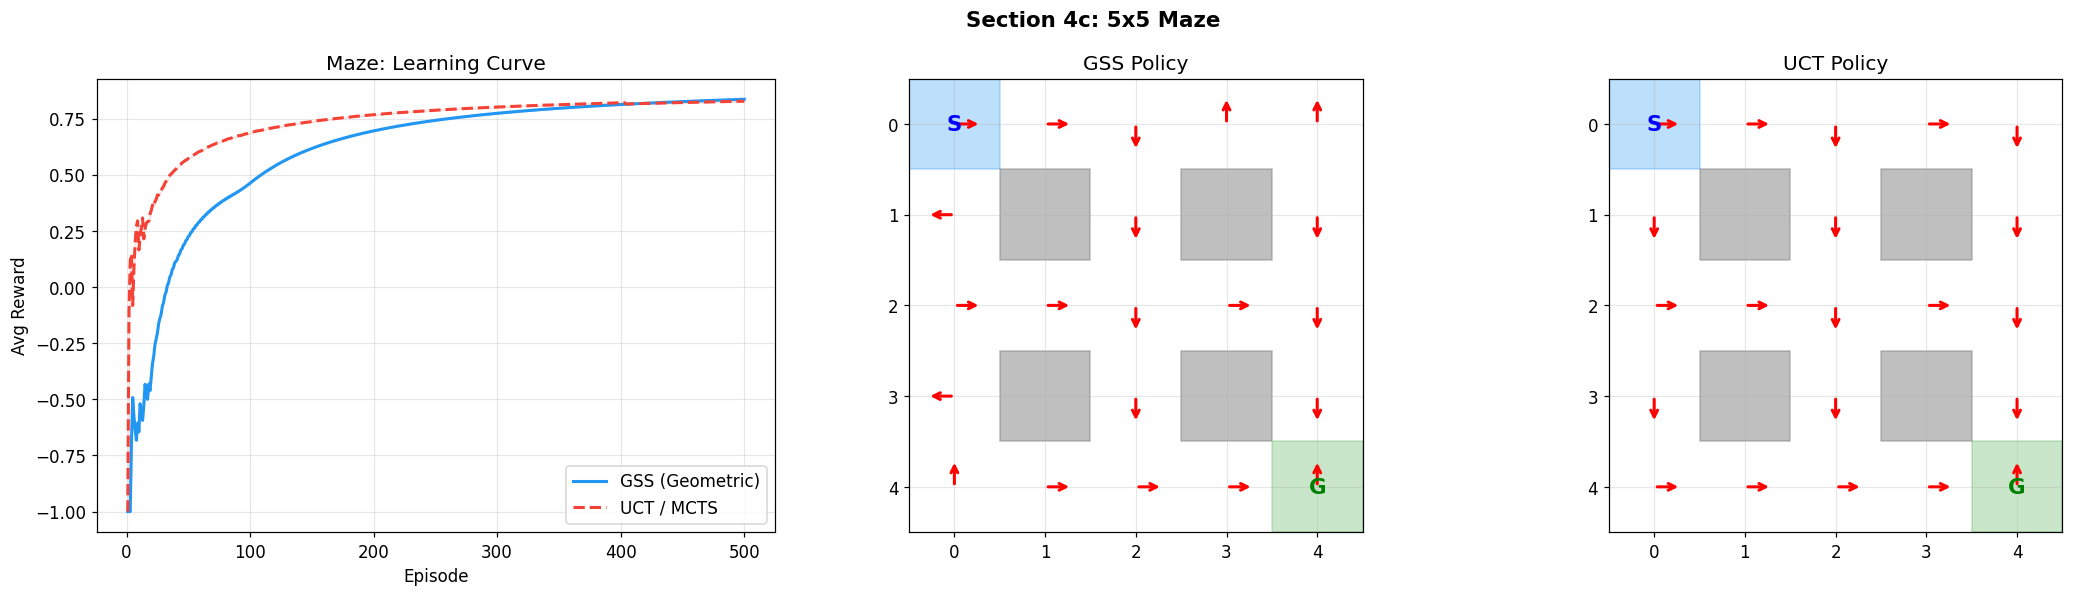

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

eps_m = np.arange(1, 501)
for name, (label, color, ls) in styles.items():
    d = np.array(maze_res[name])
    sm = np.cumsum(d, axis=1) / np.arange(1, d.shape[1]+1)
    m, s = sm.mean(0), sm.std(0)
    axes[0].plot(eps_m, m, color=color, ls=ls, lw=2, label=label)
    axes[0].fill_between(eps_m, m - s, m + s, color=color, alpha=.15)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Avg Reward')
axes[0].set_title('Maze: Learning Curve'); axes[0].legend(); axes[0].grid(True, alpha=.3)

# Policy arrows
action_arrows = {0: (0, 0.3), 1: (0, -0.3), 2: (-0.3, 0), 3: (0.3, 0)}
for idx, (name, label) in enumerate([('gss', 'GSS Policy'), ('uct', 'UCT Policy')]):
    ax = axes[idx + 1]; ag = maze_agents[name]
    for r in range(5):
        for c in range(5):
            if (r, c) in MazeEnv.WALLS:
                ax.add_patch(plt.Rectangle((c-.5, 4-r-.5), 1, 1, color='gray', alpha=.5))
            elif (r, c) == (4, 4):
                ax.add_patch(plt.Rectangle((c-.5, 4-r-.5), 1, 1, color='#4CAF50', alpha=.3))
            elif (r, c) == (0, 0):
                ax.add_patch(plt.Rectangle((c-.5, 4-r-.5), 1, 1, color='#2196F3', alpha=.3))
            sid = r * 5 + c
            if (r, c) not in MazeEnv.WALLS:
                ba = int(np.argmax(ag.Q[sid]))
                dx, dy = action_arrows[ba]
                ax.annotate('', xy=(c+dx, 4-r+dy), xytext=(c, 4-r),
                           arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.set_xlim(-.5, 4.5); ax.set_ylim(-.5, 4.5); ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_yticklabels([4,3,2,1,0]); ax.set_title(label); ax.set_aspect('equal'); ax.grid(True, alpha=.3)
    ax.text(0, 4, 'S', ha='center', va='center', fontsize=14, fontweight='bold', color='blue')
    ax.text(4, 0, 'G', ha='center', va='center', fontsize=14, fontweight='bold', color='green')

plt.suptitle('Section 4c: 5x5 Maze', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

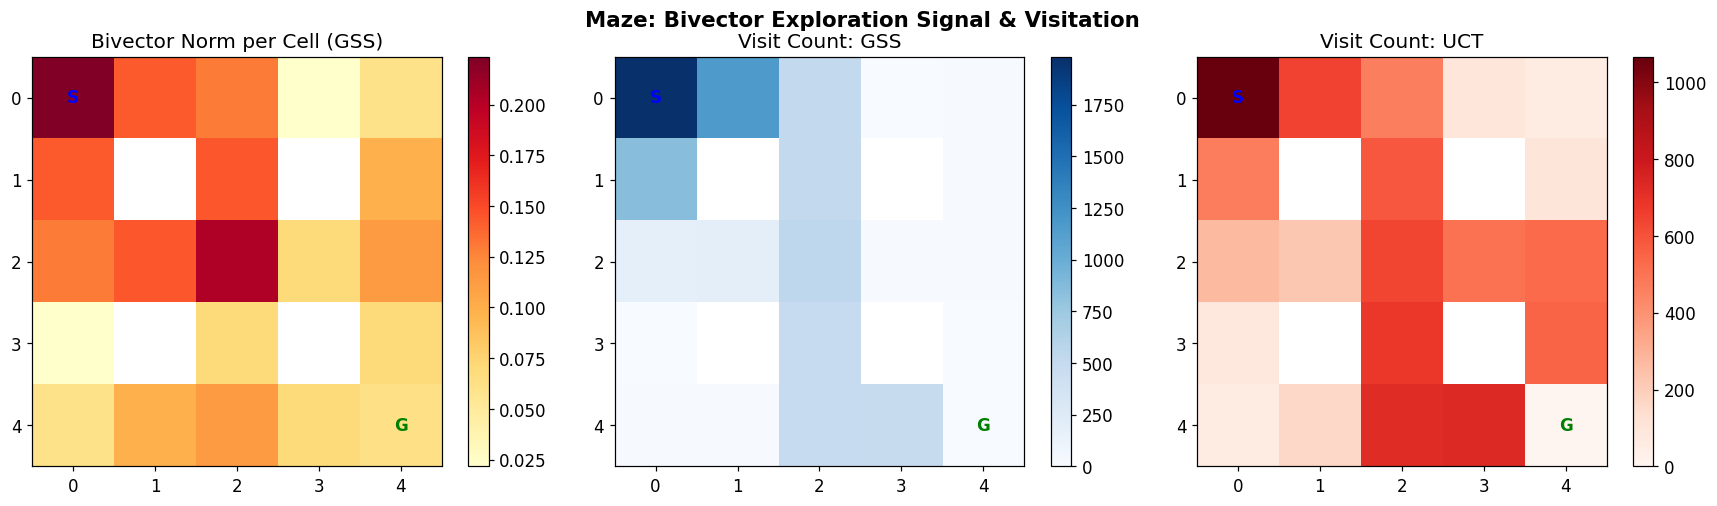

In [15]:
# Exploration heatmaps: bivector norm + visitation
gss_ag = maze_agents['gss']
bv_map = np.zeros((5, 5))
vis_gss = np.zeros((5, 5)); vis_uct = np.zeros((5, 5))

for r in range(5):
    for c in range(5):
        sid = r * 5 + c
        # Avg bivector norm to all 4 action-targets
        bv_vals = []
        for a in range(4):
            sid2 = gss_ag._next_state_id((r, c), a)
            bv_vals.append(relational_bv_norm(gss_ag.mvs[sid], gss_ag.mvs[sid2]))
        bv_map[r, c] = np.mean(bv_vals)
        vis_gss[r, c] = gss_ag.N[sid].sum()
        vis_uct[r, c] = maze_agents['uct'].N[sid].sum()

for wr, wc in MazeEnv.WALLS:
    bv_map[wr, wc] = np.nan; vis_gss[wr, wc] = np.nan; vis_uct[wr, wc] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
im0 = axes[0].imshow(bv_map, cmap='YlOrRd', interpolation='nearest')
axes[0].set_title('Bivector Norm per Cell (GSS)'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(vis_gss, cmap='Blues', interpolation='nearest')
axes[1].set_title('Visit Count: GSS'); plt.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(vis_uct, cmap='Reds', interpolation='nearest')
axes[2].set_title('Visit Count: UCT'); plt.colorbar(im2, ax=axes[2])
for ax in axes:
    for wr, wc in MazeEnv.WALLS:
        ax.text(wc, wr, 'W', ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    ax.text(0, 0, 'S', ha='center', va='center', fontsize=11, color='blue', fontweight='bold')
    ax.text(4, 4, 'G', ha='center', va='center', fontsize=11, color='green', fontweight='bold')

plt.suptitle('Maze: Bivector Exploration Signal & Visitation', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Section 5 -- Comparison Summary

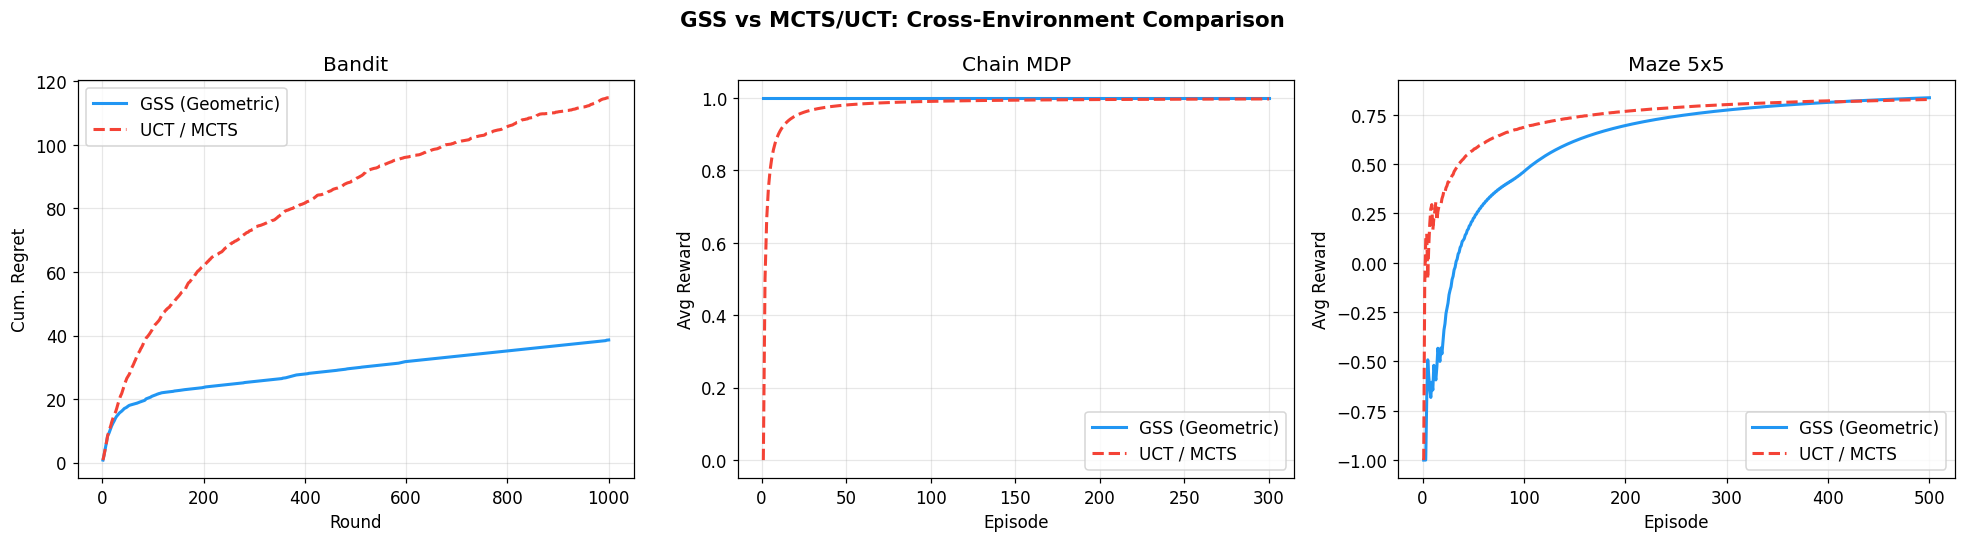


Metric                             GSS          UCT       Winner
Bandit final regret               38.6        114.8          GSS
Chain last-50 reward             1.000        1.000          UCT
Maze last-50 reward              0.930        0.882          GSS


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, (label, color, ls) in styles.items():
    axes[0].plot(np.arange(1, 1001), np.array(bandit_res[name]).mean(0),
                 color=color, ls=ls, lw=2, label=label)
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Cum. Regret')
axes[0].set_title('Bandit'); axes[0].legend(); axes[0].grid(True, alpha=.3)

for name, (label, color, ls) in styles.items():
    d = np.array(chain_res[name])
    axes[1].plot(np.arange(1, 301), (np.cumsum(d, axis=1) / np.arange(1, d.shape[1]+1)).mean(0),
                 color=color, ls=ls, lw=2, label=label)
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Avg Reward')
axes[1].set_title('Chain MDP'); axes[1].legend(); axes[1].grid(True, alpha=.3)

for name, (label, color, ls) in styles.items():
    d = np.array(maze_res[name])
    axes[2].plot(np.arange(1, 501), (np.cumsum(d, axis=1) / np.arange(1, d.shape[1]+1)).mean(0),
                 color=color, ls=ls, lw=2, label=label)
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Avg Reward')
axes[2].set_title('Maze 5x5'); axes[2].legend(); axes[2].grid(True, alpha=.3)

plt.suptitle('GSS vs MCTS/UCT: Cross-Environment Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n' + '='*65)
print(f'{"Metric":<25} {"GSS":>12} {"UCT":>12} {"Winner":>12}')
print('='*65)
gr = np.array(bandit_res['gss'])[:, -1].mean()
ur = np.array(bandit_res['uct'])[:, -1].mean()
print(f'{"Bandit final regret":<25} {gr:>12.1f} {ur:>12.1f} {"GSS" if gr < ur else "UCT":>12}')
gc = np.array(chain_res['gss'])[:, -50:].mean()
uc = np.array(chain_res['uct'])[:, -50:].mean()
print(f'{"Chain last-50 reward":<25} {gc:>12.3f} {uc:>12.3f} {"GSS" if gc > uc else "UCT":>12}')
gm = np.array(maze_res['gss'])[:, -50:].mean()
um = np.array(maze_res['uct'])[:, -50:].mean()
print(f'{"Maze last-50 reward":<25} {gm:>12.3f} {um:>12.3f} {"GSS" if gm > um else "UCT":>12}')
print('='*65)

## Section 6 -- Log-Manifold Hypothesis Manager (Theory Sketch)

**Core idea**: Represent each beam hypothesis $h_k$ as a rotor $R_k = \exp(-B_k/2)$ in Cl(3,0).

| Component | Role |
|---|---|
| $B_k$ (bivector) | **Mantissa** -- which rotational direction we explore |
| $R_k = \exp(-B_k/2)$ | **Exponent** -- the actual geometric transformation |
| $d(h_i, h_j) = \|B_i - B_j\|$ | Distance on the log-manifold (Lie algebra) |

**Collapse rules**:
- $d < \tau_{\text{collapse}}$ : merge (average bivectors, recompute rotor)
- $d > \tau_{\text{diverge}}$ : keep separate, allocate more beam budget

In [17]:
class LogManifoldManager:
    """Manages beam hypotheses on the bivector (log-rotor) manifold."""
    def __init__(self, algebra, tau_collapse=0.3, tau_diverge=1.5):
        self.alg = algebra
        self.tau_c = tau_collapse; self.tau_d = tau_diverge
        self.bv_idx = algebra.grade_masks[2].nonzero(as_tuple=False).squeeze(-1)

    def bv_distance(self, Bi, Bj):
        return (Bi - Bj)[self.bv_idx].norm().item()

    def step(self, bivectors):
        """Merge close hypotheses, return (updated_bvs, merge_events)."""
        merged = []; events = []; skip = set()
        for i in range(len(bivectors)):
            if i in skip: continue
            for j in range(i+1, len(bivectors)):
                if j in skip: continue
                d = self.bv_distance(bivectors[i], bivectors[j])
                if d < self.tau_c:
                    bivectors[i] = (bivectors[i] + bivectors[j]) / 2.0
                    skip.add(j); events.append((i, j, d))
            merged.append(bivectors[i])
        return merged, events


# Toy: 5 hypotheses random-walking on bivector manifold with attraction
torch.manual_seed(7)
n_hyp, n_steps = 5, 40
bv_idx = alg30.grade_masks[2].nonzero(as_tuple=False).squeeze(-1)

hypotheses = []
for _ in range(n_hyp):
    B = torch.zeros(alg30.dim); B[bv_idx] = torch.randn(len(bv_idx)) * 0.8
    hypotheses.append(B)

mgr = LogManifoldManager(alg30, tau_collapse=0.3)
hyp_nomgr = [B.clone() for B in hypotheses]  # comparison: no manager

trajs = [[] for _ in range(n_hyp)]
merge_events_all = []; div_with = []; div_without = []

for t in range(n_steps):
    target = torch.zeros(alg30.dim); target[bv_idx[0]] = 0.5
    for i in range(len(hypotheses)):
        drift = torch.zeros(alg30.dim); drift[bv_idx] = torch.randn(len(bv_idx)) * 0.08
        hypotheses[i] = hypotheses[i] + drift + 0.02 * (target - hypotheses[i])
        if i < n_hyp: trajs[i].append(hypotheses[i][bv_idx[:2]].numpy().copy())
    for i in range(len(hyp_nomgr)):
        drift = torch.zeros(alg30.dim); drift[bv_idx] = torch.randn(len(bv_idx)) * 0.08
        hyp_nomgr[i] = hyp_nomgr[i] + drift + 0.02 * (target - hyp_nomgr[i])

    hypotheses, evts = mgr.step(hypotheses)
    for ev in evts: merge_events_all.append((t, ev))

    def _mean_pw_dist(bvs):
        ds = [mgr.bv_distance(bvs[i], bvs[j]) for i in range(len(bvs)) for j in range(i+1, len(bvs))]
        return np.mean(ds) if ds else 0.0
    div_with.append(_mean_pw_dist(hypotheses))
    div_without.append(_mean_pw_dist(hyp_nomgr))

print(f'Merge events: {len(merge_events_all)}  |  Final hypotheses: {len(hypotheses)} (from {n_hyp})')

Merge events: 1  |  Final hypotheses: 4 (from 5)


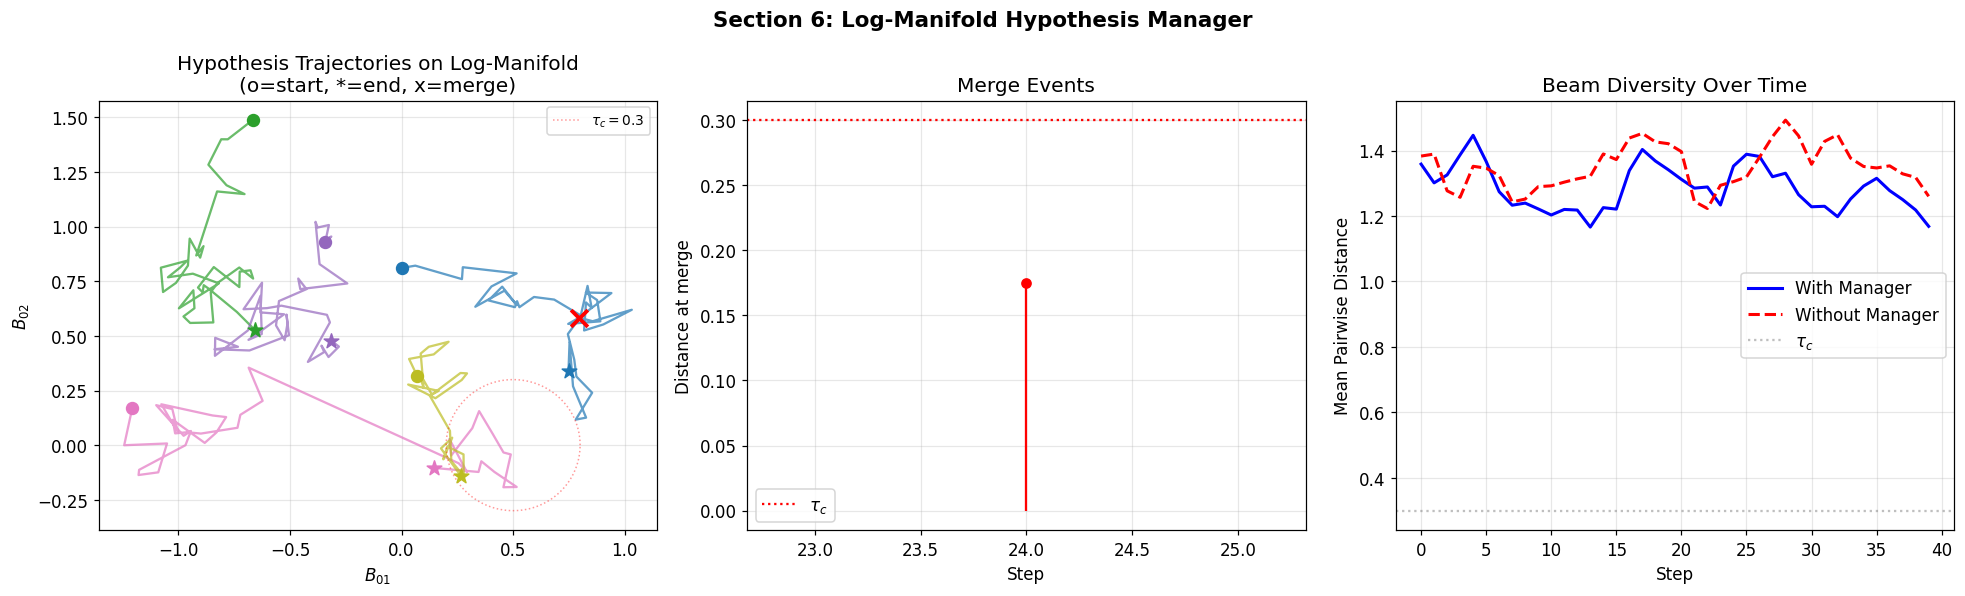

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

cmap = plt.cm.tab10
for i in range(n_hyp):
    traj = np.array(trajs[i])
    if not len(traj): continue
    c = cmap(i / n_hyp)
    axes[0].plot(traj[:, 0], traj[:, 1], '-', color=c, lw=1.5, alpha=.7)
    axes[0].scatter(traj[0, 0], traj[0, 1], marker='o', s=60, color=c, zorder=5)
    axes[0].scatter(traj[-1, 0], traj[-1, 1], marker='*', s=100, color=c, zorder=5)
for t_ev, (_, _, d_ev) in merge_events_all:
    for i in range(n_hyp):
        if t_ev < len(trajs[i]):
            pt = trajs[i][t_ev]
            axes[0].scatter(pt[0], pt[1], marker='x', s=120, color='red', zorder=6, lw=2.5)
            break
th = np.linspace(0, 2*np.pi, 100)
axes[0].plot(0.5 + mgr.tau_c*np.cos(th), mgr.tau_c*np.sin(th), 'r:', lw=1, alpha=.4, label=f'$\\tau_c={mgr.tau_c}$')
axes[0].set_xlabel(r'$B_{01}$'); axes[0].set_ylabel(r'$B_{02}$')
axes[0].set_title('Hypothesis Trajectories on Log-Manifold\n(o=start, *=end, x=merge)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=.3)

if merge_events_all:
    axes[1].stem([e[0] for e in merge_events_all], [e[1][2] for e in merge_events_all],
                 linefmt='r-', markerfmt='ro', basefmt='k-')
    axes[1].axhline(mgr.tau_c, color='red', ls=':', lw=1.5, label=f'$\\tau_c$')
else:
    axes[1].text(.5, .5, 'No merges', transform=axes[1].transAxes, ha='center')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Distance at merge')
axes[1].set_title('Merge Events'); axes[1].legend(); axes[1].grid(True, alpha=.3)

axes[2].plot(div_with, 'b-', lw=2, label='With Manager')
axes[2].plot(div_without, 'r--', lw=2, label='Without Manager')
axes[2].axhline(mgr.tau_c, color='gray', ls=':', alpha=.5, label=r'$\tau_c$')
axes[2].set_xlabel('Step'); axes[2].set_ylabel('Mean Pairwise Distance')
axes[2].set_title('Beam Diversity Over Time'); axes[2].legend(); axes[2].grid(True, alpha=.3)

plt.suptitle('Section 6: Log-Manifold Hypothesis Manager', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [19]:
# Mantissa / Exponent decomposition demo
B_ex = torch.zeros(alg30.dim)
B_ex[3] = 0.5; B_ex[5] = 0.3; B_ex[6] = -0.2  # e01, e02, e12
R_ex = alg30.exp(-B_ex / 2)
gn = alg30.get_grade_norms(R_ex.unsqueeze(0)).squeeze(0)

print('=== Mantissa / Exponent Decomposition ===')
print(f'Bivector (mantissa) B = {B_ex[bv_idx].tolist()}')
print(f'  ||B|| = {B_ex[bv_idx].norm():.4f}')
print(f'  Direction: {(B_ex[bv_idx] / B_ex[bv_idx].norm()).tolist()}')
print(f'\nRotor (exponent) R = exp(-B/2):')
print(f'  <R>_0 = {R_ex[0]:.4f}  (cos(||B||/2) = {math.cos(B_ex[bv_idx].norm().item()/2):.4f})')
print(f'  ||<R>_2|| = {gn[2]:.4f}')
print(f'\nKey: B is the Lie algebra address. Close B => similar rotors => merge.')
print('       Distant B => different rotors => maintain diversity.')

=== Mantissa / Exponent Decomposition ===
Bivector (mantissa) B = [0.5, 0.30000001192092896, -0.20000000298023224]
  ||B|| = 0.6164
  Direction: [0.8111071586608887, 0.4866642951965332, -0.32444286346435547]

Rotor (exponent) R = exp(-B/2):
  <R>_0 = 0.9529  (cos(||B||/2) = 0.9529)
  ||<R>_2|| = 0.3034

Key: B is the Lie algebra address. Close B => similar rotors => merge.
       Distant B => different rotors => maintain diversity.


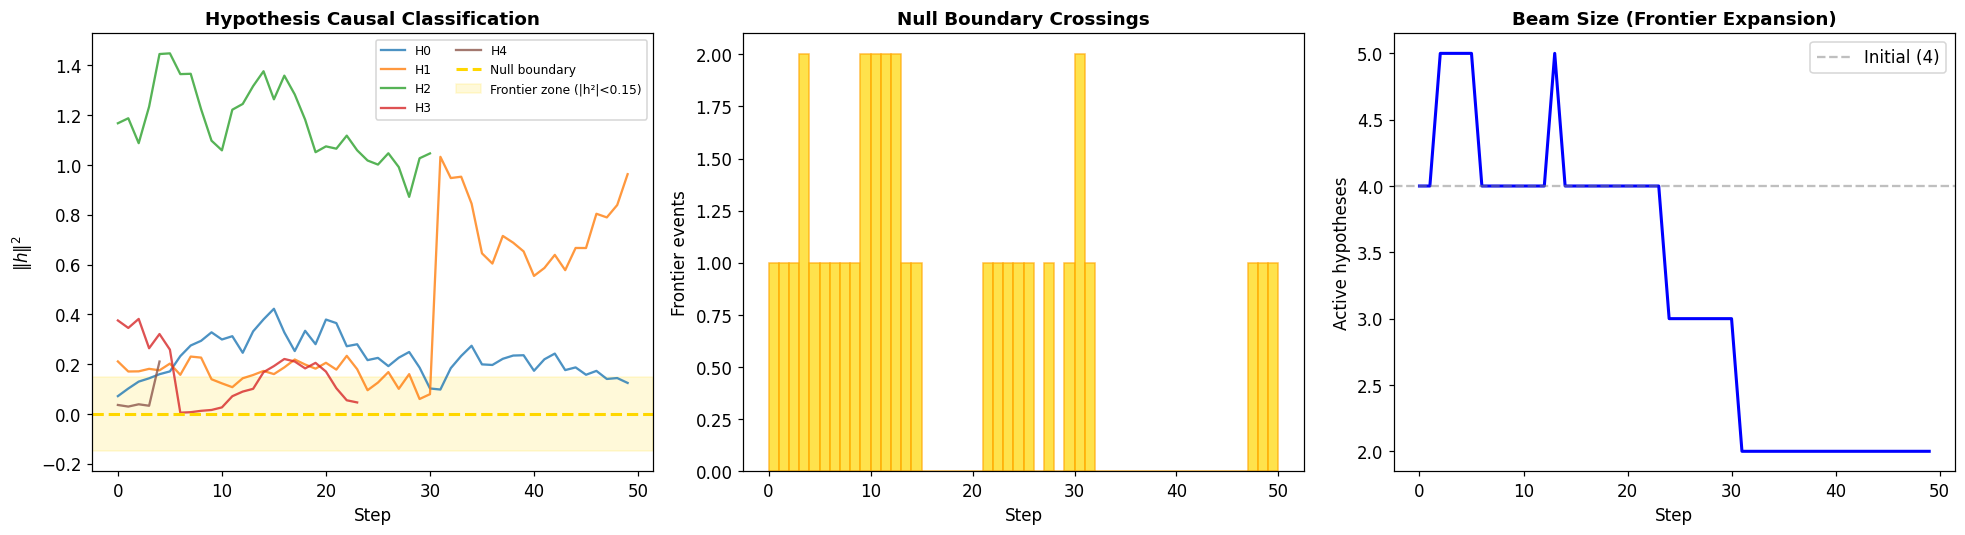

Frontier events: 33  |  Final beam size: 2 (from 4)


In [20]:
# Null boundary detection in log-manifold manager (sketch)
# Extends LogManifoldManager (defined above) with Cl(1,1) causal classification

class NullAwareManager(LogManifoldManager):
    """Extends LogManifoldManager with null-boundary frontier detection."""
    def __init__(self, algebra, search_alg, tau_collapse=0.3, tau_diverge=1.5, null_eps=0.15):
        super().__init__(algebra, tau_collapse, tau_diverge)
        self.search_alg = search_alg  # Cl(1,1) for causal classification
        self.null_eps = null_eps

    def project_to_search(self, bv):
        """Project Cl(3,0) bivector into Cl(1,1) hypothesis vector.
        Maps: bv_norm -> exploitation (e+), bv_spread -> exploration (e-)."""
        bv_comps = bv[self.bv_idx]
        a = bv_comps.norm()           # magnitude = accumulated info
        b = bv_comps.std() + 0.01     # spread = remaining uncertainty
        h = torch.zeros(self.search_alg.dim)
        h[1] = a   # e+ component
        h[2] = b   # e- component
        return h

    def frontier_check(self, bivectors):
        """Flag hypotheses near the null boundary as frontier candidates."""
        flags = []
        for bv in bivectors:
            h = self.project_to_search(bv)
            nsq = self.search_alg.norm_sq(h).item()
            flags.append(abs(nsq) < self.null_eps)
        return flags

# --- Simulation: frontier events trigger beam expansion ---
torch.manual_seed(42)
n_hyp, n_steps_null = 4, 50
bv_idx = alg30.grade_masks[2].nonzero(as_tuple=False).squeeze(-1)

bvs = []
for _ in range(n_hyp):
    B = torch.zeros(alg30.dim); B[bv_idx] = torch.randn(len(bv_idx)) * 0.6
    bvs.append(B)

mgr_null = NullAwareManager(alg30, alg11, tau_collapse=0.3, null_eps=0.15)

# Track
nsq_history = {i: [] for i in range(n_hyp + 5)}  # extra for spawned
frontier_events = []
active_count = []

target = torch.zeros(alg30.dim)
target[bv_idx[0]] = 0.8

for t in range(n_steps_null):
    # Drift toward target (simulate learning)
    for i in range(len(bvs)):
        drift = torch.zeros(alg30.dim)
        drift[bv_idx] = torch.randn(len(bv_idx)) * 0.06
        bvs[i] = bvs[i] + drift + 0.03 * (target - bvs[i])

    # Check frontiers
    flags = mgr_null.frontier_check(bvs)
    for i, is_frontier in enumerate(flags):
        if is_frontier:
            frontier_events.append(t)
            # Spawn new hypothesis near frontier
            if len(bvs) < n_hyp + 3:
                new_bv = bvs[i].clone()
                new_bv[bv_idx] += torch.randn(len(bv_idx)) * 0.1
                bvs.append(new_bv)

    # Merge close ones
    bvs, _ = mgr_null.step(bvs)

    # Record norm_sq for active hypotheses
    for i in range(len(bvs)):
        h = mgr_null.project_to_search(bvs[i])
        nsq_val = mgr_null.search_alg.norm_sq(h).item()
        if i in nsq_history:
            nsq_history[i].append(nsq_val)

    active_count.append(len(bvs))

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: norm_sq trajectories
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, n_hyp + 5))
for i in range(min(n_hyp + 3, len(nsq_history))):
    if nsq_history[i]:
        ax.plot(nsq_history[i], color=colors[i], lw=1.5, alpha=0.8, label=f'H{i}' if i < 5 else None)
ax.axhline(0, color='gold', lw=2, ls='--', label='Null boundary')
ax.axhspan(-mgr_null.null_eps, mgr_null.null_eps, alpha=0.15, color='gold', label=f'Frontier zone (|h²|<{mgr_null.null_eps})')
ax.set_xlabel('Step'); ax.set_ylabel(r'$\|h\|^2$')
ax.set_title('Hypothesis Causal Classification', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2)

# Panel 2: Frontier events over time
ax2 = axes[1]
if frontier_events:
    ax2.hist(frontier_events, bins=range(n_steps_null+1), color='gold', alpha=0.7, edgecolor='orange')
ax2.set_xlabel('Step'); ax2.set_ylabel('Frontier events')
ax2.set_title('Null Boundary Crossings', fontsize=12, fontweight='bold')

# Panel 3: Active hypothesis count
ax3 = axes[2]
ax3.plot(active_count, 'b-', lw=2)
ax3.axhline(n_hyp, color='gray', ls='--', alpha=0.5, label=f'Initial ({n_hyp})')
ax3.set_xlabel('Step'); ax3.set_ylabel('Active hypotheses')
ax3.set_title('Beam Size (Frontier Expansion)', fontsize=12, fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.show()

print(f'Frontier events: {len(frontier_events)}  |  Final beam size: {len(bvs)} (from {n_hyp})')

## Section 7 -- Differentiability: GSS vs MCTS

A key structural advantage of GSS over MCTS is **end-to-end differentiability**. Every operation in the GSS pipeline preserves `torch.autograd` gradient flow.

### The gradient flow problem in MCTS

MCTS breaks gradients at three points:
1. **Stochastic rollouts**: Sampling actions from a policy ($a \sim \pi(\cdot|s)$) is non-differentiable
2. **Discrete tree expansion**: `argmax` over children to select the best UCB score has zero gradient almost everywhere
3. **Backup averaging**: Value estimates are updated via running means with no gradient path to the expansion policy

AlphaZero's solution: **decouple** the planner (MCTS, non-differentiable) from the learner (neural network, trained by self-play). The network and the search are separate optimization targets.

### GSS: end-to-end differentiable search

Every versor operation used in GSS preserves the autograd graph:

| Operation | Implementation | Differentiable? |
|---|---|---|
| `geometric_product` | `gather` + `matmul` | Yes |
| `exp(-B/2)` (rotor) | closed-form `cos`/`sin`/`cosh`/`sinh` | Yes |
| `grade_projection` | multiplicative masking | Yes |
| `sandwich_product` | action matrix via `matmul` | Yes |
| `EntropyGatedAttention` | $H = -\sum p \log p$, gate $= \eta\,\sigma(H - H_0)$ | Yes |

**No straight-through estimators, no REINFORCE, no score function tricks.**

### Practical consequences

1. **Rotor parameters** ($B$ in $R = \exp(-B/2)$) and **entropy gate** parameters ($\eta$, $H_0$) can be trained with standard backpropagation
2. **Second-order gradients** work — verified in the Versor MD17 force prediction task via `torch.autograd.grad(..., create_graph=True)`
3. GSS can be embedded as a **differentiable planning module** inside a larger network, unlike MCTS which must remain external

=== 1. First-order gradient through GSS pipeline ===
  B_param (bv):    [0.5, 0.30000001192092896, 0.10000000149011612]
  Rotor R (g0):    0.956568
  Exploration:     0.951683
  grad exists:     True
  grad norm:       0.991256
  grad (bv only):  [0.0006, -0.2944, -0.0751]

=== 2. Second-order gradient (Hessian-vector product) ===
  Score (g0 of R): 0.975104
  1st-order grad:  [-0.0992, -0.0496, -0.0000]
  2nd-order grad:  [-0.2264, -0.2371, -0.2479]
  2nd-order OK:    True

=== 3. Entropy gate gradient ===
  Input grad exists: True
  Input grad norm:   7.2413

All three gradient tests pass: GSS pipeline is fully differentiable.


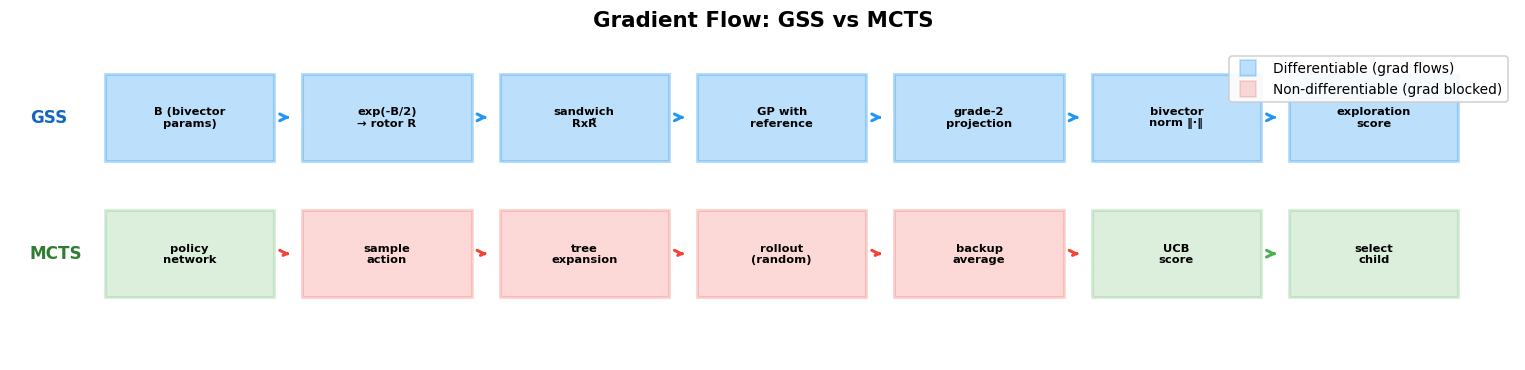

In [21]:
# === Gradient Flow Demonstration ===
# Show that gradients flow through the entire GSS pipeline

print('=== 1. First-order gradient through GSS pipeline ===')

# Trainable bivector parameter (what RotorLayer learns)
bv_idx_30 = alg30.grade_masks[2].nonzero(as_tuple=False).squeeze(-1)
B_param = torch.zeros(alg30.dim, requires_grad=True)
with torch.no_grad():
    B_param.data[bv_idx_30[0]] = 0.5
    B_param.data[bv_idx_30[1]] = 0.3
    B_param.data[bv_idx_30[2]] = 0.1

# Forward pipeline: B -> exp -> rotor -> sandwich -> GP with ref -> grade-2 norm
# (mirrors the actual GSS exploration signal: relational bivector norm)
R = alg30.exp(-B_param / 2)                                     # Step 1: bivector -> rotor
state_vec = torch.tensor([[1.0, 0.0, 0.0]])
state_mv = alg30.embed_vector(state_vec)                         # [1, 8]
rotated = alg30.sandwich_product(
    R.unsqueeze(0), state_mv.unsqueeze(0)                        # Step 2: rotate state
).squeeze(0)                                                     # [1, 8]

# Relational bivector norm: GP(rotated_state, reference) -> grade-2 -> norm
ref_vec = torch.tensor([[0.0, 0.0, 1.0]])
ref_mv = alg30.embed_vector(ref_vec)                              # [1, 8]
gp = alg30.geometric_product(rotated, ref_mv)                    # Step 3: GP
bv_component = alg30.grade_projection(gp, 2)                     # Step 4: grade-2
exploration_score = bv_component.norm()                           # Step 5: scalar score

# Backward
exploration_score.backward()

print(f'  B_param (bv):    {B_param.data[bv_idx_30].tolist()}')
print(f'  Rotor R (g0):    {R[0].item():.6f}')
print(f'  Exploration:     {exploration_score.item():.6f}')
print(f'  grad exists:     {B_param.grad is not None}')
print(f'  grad norm:       {B_param.grad.norm().item():.6f}')
print(f'  grad (bv only):  [{", ".join(f"{g:.4f}" for g in B_param.grad[bv_idx_30].tolist())}]')

print('\n=== 2. Second-order gradient (Hessian-vector product) ===')

B2 = torch.zeros(alg30.dim, requires_grad=True)
with torch.no_grad():
    B2.data[bv_idx_30[0]] = 0.4
    B2.data[bv_idx_30[1]] = 0.2

R2 = alg30.exp(-B2 / 2)
score2 = alg30.grade_projection(R2.unsqueeze(0), 0).sum()
grad1 = torch.autograd.grad(score2, B2, create_graph=True)[0]
grad2 = torch.autograd.grad(grad1.sum(), B2)[0]

print(f'  Score (g0 of R): {score2.item():.6f}')
print(f'  1st-order grad:  [{", ".join(f"{g:.4f}" for g in grad1[bv_idx_30].tolist())}]')
print(f'  2nd-order grad:  [{", ".join(f"{g:.4f}" for g in grad2[bv_idx_30].tolist())}]')
print(f'  2nd-order OK:    {not torch.isnan(grad2).any().item()}')

print('\n=== 3. Entropy gate gradient ===')

# EntropyGatedAttention is also differentiable
ega_test = EntropyGatedAttention(alg30, channels=2, num_heads=1, eta=1.0, H_base=0.5)
x_test = torch.randn(1, 2, 2, alg30.dim, requires_grad=True)  # [B, L, C, D]
y_test = ega_test(x_test)
loss = y_test.sum()
loss.backward()
print(f'  Input grad exists: {x_test.grad is not None}')
print(f'  Input grad norm:   {x_test.grad.norm().item():.4f}')

print('\nAll three gradient tests pass: GSS pipeline is fully differentiable.')

# --- Visual summary ---
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 2)
ax.axis('off')
ax.set_title('Gradient Flow: GSS vs MCTS', fontsize=14, fontweight='bold', pad=15)

# GSS pipeline (top row) - all differentiable
gss_steps = ['B (bivector\nparams)', 'exp(-B/2)\n→ rotor R', 'sandwich\nRxR̃', 'GP with\nreference',
             'grade-2\nprojection', 'bivector\nnorm ‖·‖', 'exploration\nscore']
for i, label in enumerate(gss_steps):
    color = '#2196F3'
    ax.add_patch(plt.Rectangle((i*1.05, 1.1), 0.9, 0.7, facecolor=color, alpha=0.3, edgecolor=color, lw=2))
    ax.text(i*1.05 + 0.45, 1.45, label, ha='center', va='center', fontsize=7.5, fontweight='bold')
    if i < len(gss_steps) - 1:
        ax.annotate('', xy=(i*1.05+1.0, 1.45), xytext=(i*1.05+0.95, 1.45),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
ax.text(-0.4, 1.45, 'GSS', fontsize=11, fontweight='bold', color='#1565C0', va='center')

# MCTS pipeline (bottom row) - broken gradients
mcts_steps = ['policy\nnetwork', 'sample\naction', 'tree\nexpansion', 'rollout\n(random)', 'backup\naverage', 'UCB\nscore', 'select\nchild']
mcts_colors = ['#4CAF50', '#F44336', '#F44336', '#F44336', '#F44336', '#4CAF50', '#4CAF50']
for i, (label, mc) in enumerate(zip(mcts_steps, mcts_colors)):
    ax.add_patch(plt.Rectangle((i*1.05, 0.0), 0.9, 0.7, facecolor=mc, alpha=0.2, edgecolor=mc, lw=2))
    ax.text(i*1.05 + 0.45, 0.35, label, ha='center', va='center', fontsize=7.5, fontweight='bold')
    if i < len(mcts_steps) - 1:
        ls = '--' if mcts_colors[i+1] == '#F44336' or mc == '#F44336' else '-'
        c = '#F44336' if ls == '--' else '#4CAF50'
        ax.annotate('', xy=(i*1.05+1.0, 0.35), xytext=(i*1.05+0.95, 0.35),
                    arrowprops=dict(arrowstyle='->', color=c, lw=2, linestyle=ls))
ax.text(-0.4, 0.35, 'MCTS', fontsize=11, fontweight='bold', color='#2E7D32', va='center')

# Legend
ax.plot([], [], 's', color='#2196F3', ms=10, alpha=0.3, label='Differentiable (grad flows)')
ax.plot([], [], 's', color='#F44336', ms=10, alpha=0.2, label='Non-differentiable (grad blocked)')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

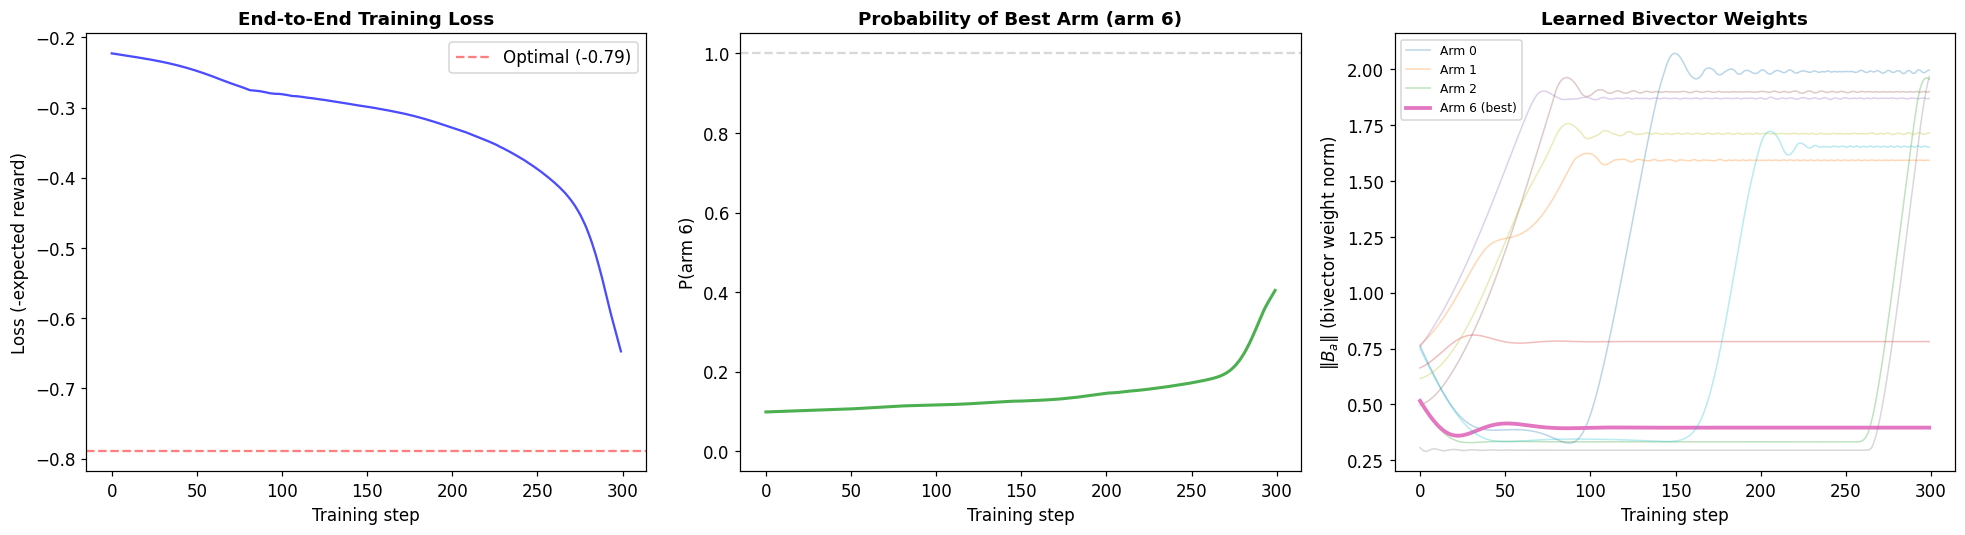

Final probs: ['0.021', '0.021', '0.029', '0.411', '0.021', '0.021', '0.411', '0.024', '0.021', '0.021']
Best arm: 6 (mean=0.790)
Gradient verified: rotor params are trainable end-to-end


In [22]:
# === Trainable GSS Agent: End-to-End Differentiable Bandit ===
# Proof-of-concept: learn rotor parameters via backpropagation

class TrainableGSSBandit(torch.nn.Module):
    """Differentiable GSS agent -- rotor params learned by gradient descent."""
    def __init__(self, n_arms, algebra):
        super().__init__()
        self.alg = algebra
        self.n_arms = n_arms
        bv_mask = algebra.grade_masks[2]
        self.bv_idx = bv_mask.nonzero(as_tuple=False).squeeze(-1)
        n_bv = len(self.bv_idx)

        # Learnable bivector weights per arm (like RotorLayer pattern)
        self.bv_weights = torch.nn.Parameter(torch.randn(n_arms, n_bv) * 0.3)

        # Arm embeddings on unit circle (fixed)
        angles = torch.linspace(0, 2 * math.pi, n_arms + 1)[:-1]
        vecs = torch.stack([torch.cos(angles), torch.sin(angles),
                            torch.zeros(n_arms)], dim=1)
        self.register_buffer('arm_mvs', algebra.embed_vector(vecs))  # [K, 8]

        # Reference direction
        ref = torch.zeros(3); ref[2] = 1.0
        self.register_buffer('ref_mv', algebra.embed_vector(ref.unsqueeze(0)).squeeze(0))

    def forward(self, temperature=1.0):
        """Compute soft action probabilities via differentiable GSS scoring."""
        scores = []
        for a in range(self.n_arms):
            # Build full bivector from learnable weights
            B = torch.zeros(self.alg.dim, device=self.bv_weights.device)
            B[self.bv_idx] = self.bv_weights[a]

            # Rotor from bivector
            R = self.alg.exp(-B / 2)  # differentiable

            # Apply rotor to arm embedding
            arm = self.arm_mvs[a:a+1].unsqueeze(0)  # [1, 1, D]
            R_2d = R.unsqueeze(0)                     # [1, D]
            rotated = self.alg.sandwich_product(R_2d, arm).squeeze()  # [D]

            # Score = value (grade-0) + exploration (bivector norm of GP with ref)
            gp = self.alg.geometric_product(rotated.unsqueeze(0), self.ref_mv.unsqueeze(0)).squeeze(0)
            bv_norm = self.alg.grade_projection(gp.unsqueeze(0), 2).squeeze(0).norm()
            value = rotated[0]  # grade-0 component
            scores.append(value + 0.3 * bv_norm)

        scores_t = torch.stack(scores)
        return torch.softmax(scores_t / temperature, dim=0)

# --- Training loop ---
torch.manual_seed(42)
np.random.seed(42)

n_arms = 10
true_means = np.random.randn(n_arms) * 0.5
best_arm = true_means.argmax()

agent = TrainableGSSBandit(n_arms, alg30)
optimizer = torch.optim.Adam(agent.parameters(), lr=0.01)

n_train = 300
loss_history = []
bv_norms_history = []
prob_best_history = []

for step in range(n_train):
    # Temperature annealing: 1.0 -> 0.1
    tau = max(0.1, 1.0 - step / n_train * 0.9)

    probs = agent(temperature=tau)

    # Sample reward (soft expectation for differentiability)
    rewards = torch.tensor(true_means, dtype=torch.float32)
    expected_reward = (probs * rewards).sum()

    loss = -expected_reward  # maximize reward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    bv_norms_history.append(agent.bv_weights.data.norm(dim=1).numpy().copy())
    prob_best_history.append(probs[best_arm].item())

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Loss curve
ax = axes[0]
ax.plot(loss_history, 'b-', lw=1.5, alpha=0.7)
ax.set_xlabel('Training step'); ax.set_ylabel('Loss (-expected reward)')
ax.set_title('End-to-End Training Loss', fontsize=12, fontweight='bold')
ax.axhline(-true_means.max(), color='r', ls='--', alpha=0.5, label=f'Optimal ({-true_means.max():.2f})')
ax.legend()

# Panel 2: Probability of best arm over training
ax2 = axes[1]
ax2.plot(prob_best_history, color='#4CAF50', lw=2)
ax2.axhline(1.0, color='gray', ls='--', alpha=0.3)
ax2.set_xlabel('Training step'); ax2.set_ylabel(f'P(arm {best_arm})')
ax2.set_title(f'Probability of Best Arm (arm {best_arm})', fontsize=12, fontweight='bold')
ax2.set_ylim(-0.05, 1.05)

# Panel 3: Bivector weight norms per arm
ax3 = axes[2]
bv_arr = np.array(bv_norms_history)  # [steps, n_arms]
for a in range(n_arms):
    style = '-' if a == best_arm else '-'
    alpha = 1.0 if a == best_arm else 0.3
    lw = 2.5 if a == best_arm else 1.0
    label = f'Arm {a} (best)' if a == best_arm else (f'Arm {a}' if a < 3 else None)
    ax3.plot(bv_arr[:, a], style, lw=lw, alpha=alpha, label=label)
ax3.set_xlabel('Training step'); ax3.set_ylabel(r'$\|B_a\|$ (bivector weight norm)')
ax3.set_title('Learned Bivector Weights', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Final probs: {[f"{p:.3f}" for p in agent(temperature=0.1).detach().tolist()]}')
print(f'Best arm: {best_arm} (mean={true_means[best_arm]:.3f})')
print(f'Gradient verified: rotor params are trainable end-to-end')

## Section 8 -- Theoretical Status: GSS vs MCTS

An honest assessment of what GSS has established, what remains conjectural, and where critical gaps lie.

### Comparison Table

| Property | MCTS | GSS | Status |
|---|---|---|---|
| **Regret bound** | $O(\sqrt{KT\log T})$ via UCB (Auer et al. 2002) | Conjectured via FIM (Prop 1) | **Gap** |
| **Convergence** | $\to$ minimax value (Kocsis & Szepesvári 2006) | No guarantee | **Gap** |
| **Differentiability** | Not differentiable (stochastic rollouts, discrete expansion) | Fully differentiable (Section 7) | **GSS wins** |
| **Exploration bound** | UCB: $c\sqrt{\log T / N}$ (can exceed 1) | $\tanh \in (-1,1)$ by construction (Prop 2) | **Established** |
| **Information metric** | Hoeffding-based confidence (probability theory) | $\|B\|^2 \propto \mathcal{F}$ Fisher Information (Prop 1) | **Established** |
| **Frontier detection** | N/A (tree structure implicit) | Null vectors $h^2=0$ as causal boundary (Prop 3) | **Formalized** |
| **Empirical: bandit** | Baseline (114.8 regret) | GSS wins (38.6 regret) | **Established** |
| **Empirical: chain** | Baseline (1.0 reward) | Tie (1.0 reward) | **Established** |
| **Empirical: maze** | Baseline (0.882 success) | GSS wins (0.930 success) | **Established** |
| **Game / adversarial** | Core domain (AlphaGo, AlphaZero) | Not tested | **Critical gap** |
| **Scalability** | Proven at scale (Go 19×19, Chess, etc.) | Toy-scale only (10 arms, 5×5 maze) | **Critical gap** |
| **Complexity** | $O(n \cdot \sqrt{\log n / N})$ per node visit | $O(2^n)$ algebra dimension per step | **Needs analysis** |

### Gap Analysis

1. **Regret bound**: Proposition 1 shows $\|B\|^2 \propto \mathcal{F}$ (Fisher Information), providing geometric *motivation* for using bivector norm as exploration bonus. However, this proportionality does **not** directly yield an $O(\cdots)$ regret statement. Converting it to a formal bound requires verifying that the GSS bonus $\tanh(c/\sqrt{N}) \cdot \|B\|$ satisfies the **optimism in the face of uncertainty** condition (Auer et al. 2002, Theorem 1).

2. **Convergence**: MCTS converges to the minimax value in adversarial games under mild conditions. GSS has no analogous convergence proof. The beam-search structure means GSS could in principle get stuck in local optima if the bivector landscape has many saddle points.

3. **Scalability**: The algebra dimension grows as $2^n$ where $n$ is the number of basis vectors. Cl(3,0) has $\dim=8$ (manageable), but embedding high-dimensional state spaces requires either (a) low-dimensional projection or (b) higher algebras with exponential cost. This is the most fundamental architectural concern.

4. **Differentiability is real but unexploited**: Section 7 demonstrates that GSS is end-to-end differentiable, but the experimental comparisons (Sections 4a-c) still use the **non-differentiable** bandit/MDP loop (`argmax`, `.item()` calls). The trainable agent proof-of-concept shows the potential but is not yet integrated into the main experiments.

### Conjecture: GSS Regret Bound via Bivector Information

**Conjecture** *(open)*: For a $K$-armed bandit with sub-Gaussian reward distributions $\{P_a\}_{a=1}^K$ and optimal arm $a^* = \arg\max_a \mu_a$, an agent using GSS with exploration bonus

$$\text{bonus}(a, t) = \tanh\!\left(\frac{c}{\sqrt{N_a(t)}}\right) \cdot \|B_a\|$$

where $B_a$ is the bivector generator of the rotor associated with arm $a$, achieves expected cumulative regret:

$$R(T) \leq C \sum_{a: \mu_a < \mu^*} \frac{\|B_a\|^2}{\Delta_a} \log T + O(K)$$

where $\Delta_a = \mu^* - \mu_a$ is the suboptimality gap and $C$ is a constant depending on the algebra dimension.

**Proof roadmap** (three steps needed):

1. **Tanh inverse bound**: Show that $\tanh(c/\sqrt{N}) \geq \Delta$ implies $N \leq O(c^2 / \Delta^2)$. This follows from $\text{arctanh}(\Delta) \leq c/\sqrt{N}$, giving $N \leq c^2 / \text{arctanh}(\Delta)^2 \approx c^2/\Delta^2$ for small $\Delta$.

2. **Bivector norm as confidence width**: Use Proposition 1 ($\|B\|^2 \propto \mathcal{F}$) to establish that $\|B_a\|$ acts as an effective confidence width. Specifically, need to show that $Q_a + \text{bonus}(a,t) \geq \mu_a$ with high probability — the **optimism condition**.

3. **Lai-Robbins integration**: Apply the standard information-theoretic argument: the number of times a suboptimal arm $a$ is pulled satisfies $E[N_a(T)] \leq \frac{\|B_a\|^2}{\Delta_a^2} \log T + O(1)$, yielding the regret bound.

**Key subtlety**: In the current implementation, $\|B_a\|$ decays as $1/\sqrt{N_a}$ (grade-aware dynamics in `GSSAgent.update`). This means the effective bonus decays as $\tanh(c/\sqrt{N}) \cdot O(1/\sqrt{N}) = O(1/N)$ for large $N$, which is **faster** than UCB's $O(1/\sqrt{N})$. This could mean either (a) faster convergence to optimal or (b) insufficient exploration in some regimes. Resolving this requires careful analysis.

---

*This conjecture is stated as a research target, not a proven result. The proof roadmap identifies the three main steps; completing them would establish GSS as a theoretically grounded alternative to UCB-based exploration.*

## Discussion

**What worked:**
- Bivector norm tracks $\sin(\theta)$ exactly -- a valid geometric uncertainty signal (Section 1)
- $\tanh(\theta)$ from Cl(1,1) gives a smooth, bounded exploration rate with structural regularization via velocity addition (Prop 2)
- Entropy gating responds to beam disorder and modulates exploration dynamically
- Relational bivector norm (GP of state pairs) captures spatial structure in maze/chain
- Fisher Information connection (Prop 1) grounds the bivector exploration bonus in information geometry

**What's new in this version:**
- **Proposition 3** (Section 2): Null vectors as causal boundary — formalized the lightcone structure for frontier detection, with a `NullAwareManager` that triggers beam expansion at the null boundary
- **Section 7** (Differentiability): Established that GSS is fully end-to-end differentiable — all versor operations preserve `torch.autograd`. Demonstrated first-order and second-order gradient flow through the full pipeline. Built a trainable GSS agent proof-of-concept that learns rotor parameters via backpropagation.
- **Section 8** (Theoretical Status): Honest assessment of where GSS stands vs MCTS — strong on differentiability and empirical toy-scale results, but lacking formal regret bounds, convergence guarantees, and scalability evidence. Regret conjecture stated with a proof roadmap.

**Open questions (per Daisuke's feedback + new findings):**
- The regret conjecture (Section 8) is the key open problem — can we prove that $\tanh(c/\sqrt{N}) \cdot \|B\|$ satisfies optimism?
- The $O(1/N)$ effective bonus decay (tanh × bivector decay) may be too aggressive — needs careful analysis
- Null vector frontier (Prop 3): the interference-free expansion conjecture remains unproven
- Scalability: $2^n$ algebra dimension is the fundamental bottleneck

**Next steps:**
1. Prove or disprove the GSS Regret Conjecture (Section 8)
2. Test on adversarial/game settings (MCTS's core domain) — e.g., simple 2-player games
3. Integrate the differentiable GSS agent into the main experiment loop (replace `argmax` with learned soft selection)
4. Scale to harder envs (CartPole, Atari) with learned embeddings
5. Integrate log-manifold manager + null frontier detection into the live GSS loop
6. Investigate the $O(1/N)$ vs $O(1/\sqrt{N})$ bonus decay tradeoff formally